# Statystyka i teoria obsługi masowej - PROJEKT
## Kamil Jędrzkiewicz, Adam Kaszubowski, Radosław Szwed

## Przygotowanie zbioru danych

### Wczytanie zbioru i sprawdzenie podstawowych informacji o kolumnach (oraz wyświetlenie 3 pierwszych rekordow)

In [641]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from scipy import stats
path = Path('Sleep_health_and_lifestyle_dataset.csv')
data = pd.read_csv(path, encoding='utf-8-sig')
columns = data.columns.tolist()

print('Liczba obserwacji:', len(data))
print('Kolumny:')
print(columns)

data.head(3)

Liczba obserwacji: 374
Kolumny:
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN


### Rozbicie kolumny Blood Pressure na kolumne z ciśnieniem skurczowym i rozkurczowym

In [642]:
blood_pressure = data['Blood Pressure'].str.split('/', expand=True)
data['Systolic_BP'] = blood_pressure[0].astype(int)
data['Diastolic_BP'] = blood_pressure[1].astype(int)

data[['Blood Pressure', 'Systolic_BP', 'Diastolic_BP']].head()

,Blood Pressure,Systolic_BP,Diastolic_BP
0,126/83,126,83
1,125/80,125,80
2,125/80,125,80
3,140/90,140,90
4,140/90,140,90


### Kodowanie płci i BMI na wartośći 0/1

In [643]:
gender_mapping = {'Female': 0, 'Male': 1}
data['Gender_binary'] = data['Gender'].map(gender_mapping)

data[['Gender', 'Gender_binary']].drop_duplicates().sort_values('Gender_binary')



,Gender,Gender_binary
16,Female,0
0,Male,1


In [644]:
normal_bmi_labels = {'Normal', 'Normal Weight'}
data['BMI_binary'] = (~data['BMI Category'].isin(normal_bmi_labels)).astype(int)

data[['BMI Category', 'BMI_binary']].drop_duplicates().sort_values(['BMI_binary', 'BMI Category'])

,BMI Category,BMI_binary
1,Normal,0
16,Normal Weight,0
3,Obese,1
0,Overweight,1


### Utworzenie kopii danych tylko z potrzebnymi kolumnami.

In [645]:
prepared_columns = [
    'Person ID',
    'Gender_binary',
    'BMI_binary',
    'Systolic_BP',
    'Diastolic_BP',
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Sleep Disorder'
]


data = data[prepared_columns].copy()
data.head(10)

,Person ID,Gender_binary,BMI_binary,Systolic_BP,Diastolic_BP,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder
0,1,1,1,126,83,27,6.1,6,42,6,77,4200,NaN
1,2,1,0,125,80,28,6.2,6,60,8,75,10000,NaN
2,3,1,0,125,80,28,6.2,6,60,8,75,10000,NaN
3,4,1,1,140,90,28,5.9,4,30,8,85,3000,Sleep Apnea
4,5,1,1,140,90,28,5.9,4,30,8,85,3000,Sleep Apnea
5,6,1,1,140,90,28,5.9,4,30,8,85,3000,Insomnia
6,7,1,1,140,90,29,6.3,6,40,7,82,3500,Insomnia
7,8,1,0,120,80,29,7.8,7,75,6,70,8000,NaN
8,9,1,0,120,80,29,7.8,7,75,6,70,8000,NaN
9,10,1,0,120,80,29,7.8,7,75,6,70,8000,NaN


In [646]:
# Dodatkowe biblioteki potrzebne w analizie
import warnings
warnings.filterwarnings('ignore')

import itertools
from scipy import stats
from scipy.stats import (ttest_ind, mannwhitneyu, shapiro, levene,
                         anderson, bartlett, kruskal, f_oneway, kstest)
from statsmodels.stats.diagnostic import lilliefors
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

### Wybór zmiennych metrycznych

Analizę normalności oraz testy porównujące grupy wykonujemy dla zmiennych liczbowych.

In [647]:
metric_columns = [
    'Systolic_BP',
    'Diastolic_BP',
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps'
]

data[metric_columns].describe()

,Systolic_BP,Diastolic_BP,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,128.553476,84.649733,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,7.748118,6.161611,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,115.000000,75.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,125.000000,80.000000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,130.000000,85.000000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,135.000000,90.000000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,142.000000,95.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


### Sprawdzenie normalności zmiennych - histogramy

In [648]:
def normality_plots(df, columns):
    for column_name in columns:
        plt.hist(df[column_name], bins=30, color='lightgreen', edgecolor='black')
        plt.title(f'Histogram - {column_name}')
        plt.xlabel(column_name)
        plt.ylabel('Frequency')
        plt.show()

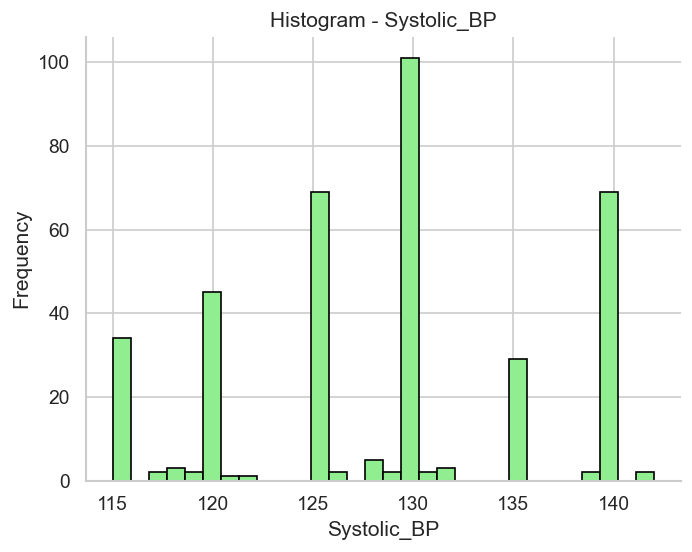

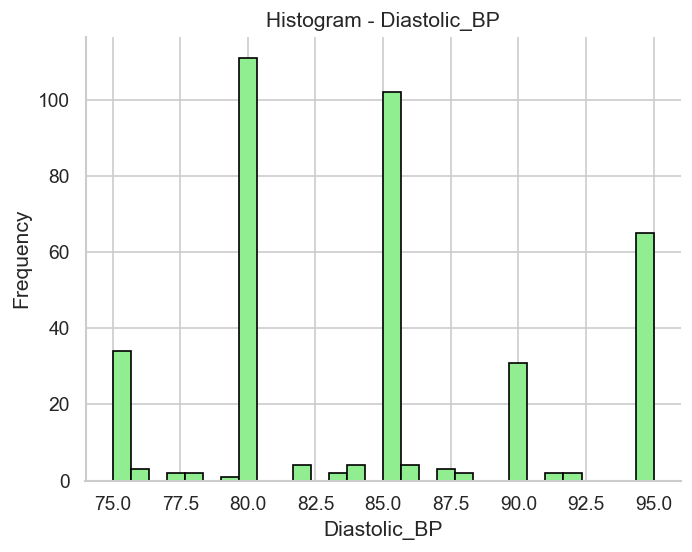

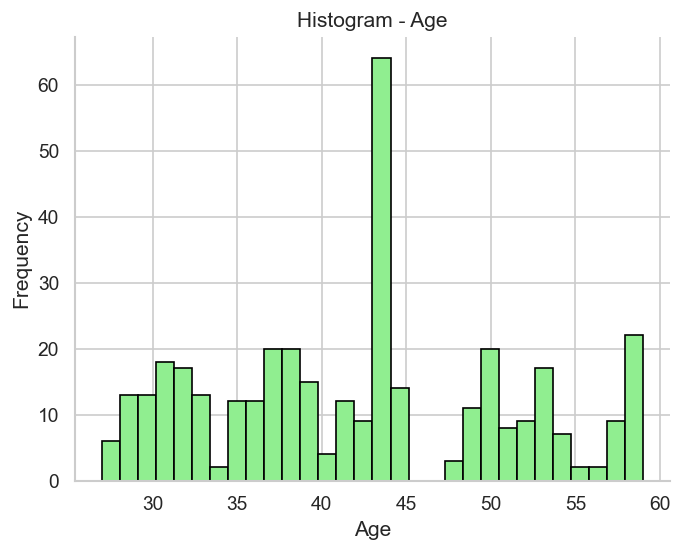

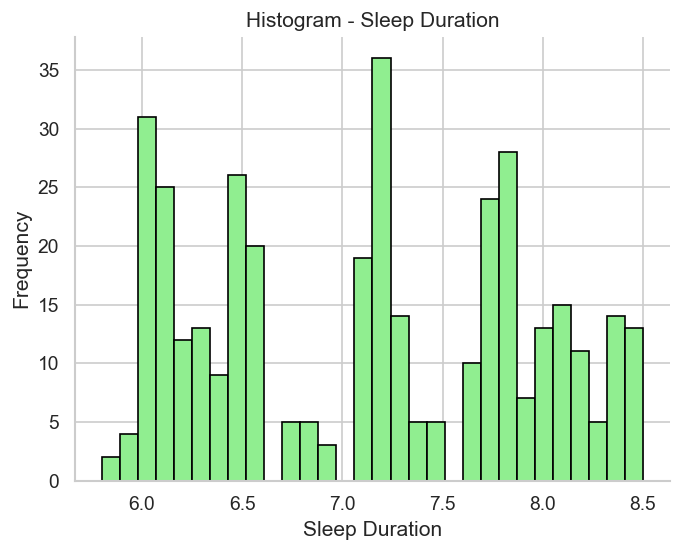

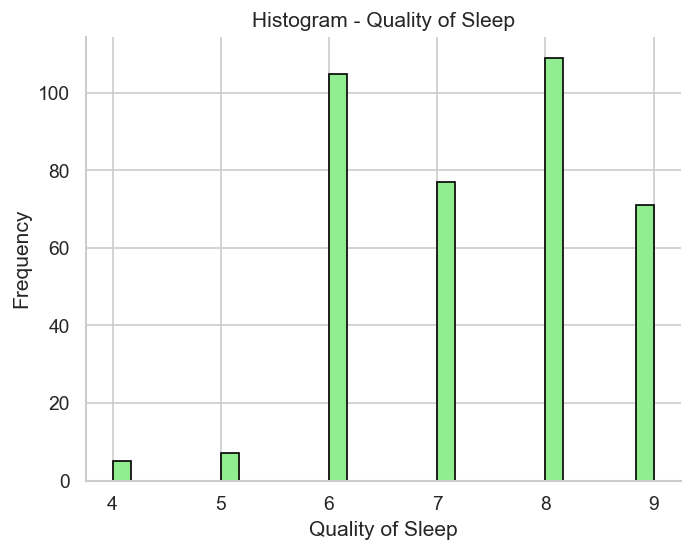

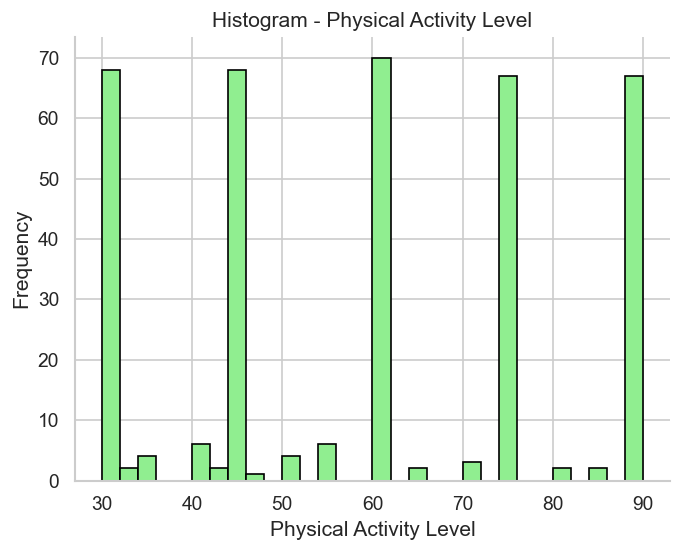

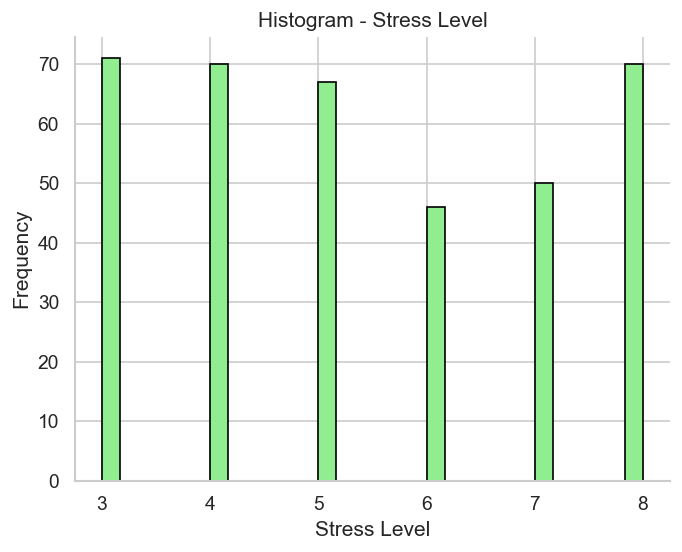

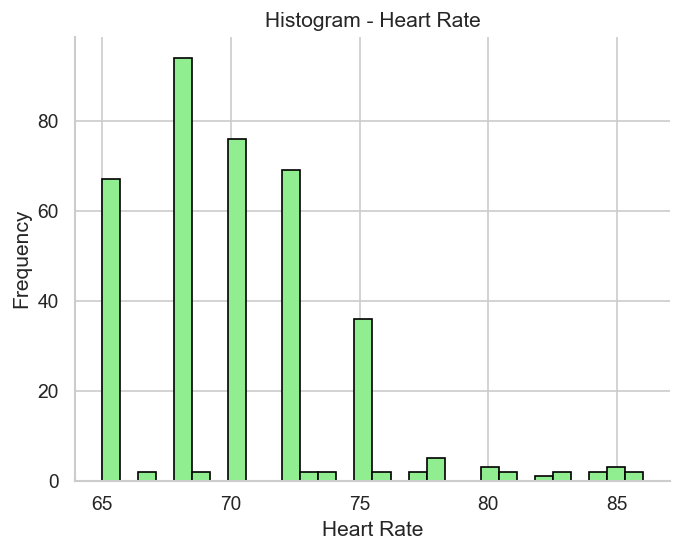

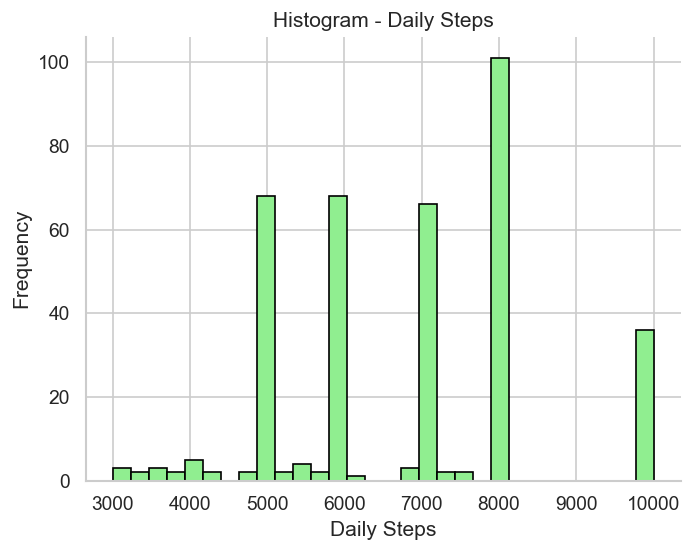

In [649]:
normality_plots(data, metric_columns)

### Sprawdzenie normalności zmiennych - test Kołmogorowa-Smirnowa

In [650]:
def kolmogorov_smirnov_test(df, columns):
    for column_name in columns:
        column = df[column_name]
        standardized_data = (column - column.mean()) / column.std()
        stat, p_value = kstest(standardized_data, 'norm')
        print(f"Test Kołmogorowa-Smirnowa dla kolumny {column_name}")
        print(f"Statystyka = {stat:.3f}")
        print(f"P-wartość = {p_value:.3f}")
        print()

In [651]:
kolmogorov_smirnov_test(data, metric_columns)

Test Kołmogorowa-Smirnowa dla kolumny Systolic_BP
Statystyka = 0.140
P-wartość = 0.000

Test Kołmogorowa-Smirnowa dla kolumny Diastolic_BP
Statystyka = 0.186
P-wartość = 0.000

Test Kołmogorowa-Smirnowa dla kolumny Age
Statystyka = 0.086
P-wartość = 0.008

Test Kołmogorowa-Smirnowa dla kolumny Sleep Duration
Statystyka = 0.128
P-wartość = 0.000

Test Kołmogorowa-Smirnowa dla kolumny Quality of Sleep
Statystyka = 0.198
P-wartość = 0.000

Test Kołmogorowa-Smirnowa dla kolumny Physical Activity Level
Statystyka = 0.153
P-wartość = 0.000

Test Kołmogorowa-Smirnowa dla kolumny Stress Level
Statystyka = 0.159
P-wartość = 0.000

Test Kołmogorowa-Smirnowa dla kolumny Heart Rate
Statystyka = 0.160
P-wartość = 0.000

Test Kołmogorowa-Smirnowa dla kolumny Daily Steps
Statystyka = 0.136
P-wartość = 0.000



P-wartości dla wszystkich kolumn są mniejsze niż 0.05, co sugeruje odrzucenie hipotezy o normalności rozkładu danych.

### Dokładniejsze testy normalności: K-S z poprawką Lillieforsa, Shapiro-Wilka i Andersona-Darlinga

Powyższy test K-S w prostej wersji nie jest do końca poprawny: porównujemy dane z rozkładem normalnym, którego **parametry (średnią i odchylenie) sami oszacowaliśmy z tych samych danych**, co czyni test zbyt łagodnym (zaniża prawdopodobieństwo odrzucenia normalności). Właściwą wersją w takiej sytuacji jest **test K-S z poprawką Lillieforsa**.

Dla pewności stosujemy dodatkowo K-S z poprawką Lillieforsa i dwa inne, czułe testy normalności: **Shapiro-Wilka** (zwykle najmocniejszy) oraz **Andersona-Darlinga** (szczególnie wrażliwy na ogony rozkładu).

In [652]:
def normality_tests(df, columns):
    rows = []
    for column_name in columns:
        s = df[column_name]

        # Test K-S z poprawką Lillieforsa
        lf_stat, lf_p = lilliefors(s, dist='norm', pvalmethod='table')

        # Test Shapiro-Wilka
        sw_stat, sw_p = shapiro(s)

        # Test Andersona-Darlinga (porównujemy statystykę z wartością krytyczną dla 5%)
        ad = anderson(s, dist='norm')
        ad_crit_5 = ad.critical_values[2]

        normal = (lf_p > 0.05) and (sw_p > 0.05) and (ad.statistic < ad_crit_5)

        rows.append({
            'Zmienna': column_name,
            'Lilliefors_p': round(lf_p, 4),
            'Shapiro_W': round(sw_stat, 3),
            'Shapiro_p': round(sw_p, 4),
            'AndersonDarling_stat': round(ad.statistic, 2),
            'AD_wart_kryt_5%': round(ad_crit_5, 2),
            'Rozkład normalny?': 'tak' if normal else 'nie'
        })
    return pd.DataFrame(rows)

normality_tests(data, metric_columns)

,Zmienna,Lilliefors_p,Shapiro_W,Shapiro_p,AndersonDarling_stat,AD_wart_kryt_5%,Rozkład normalny?
0,Systolic_BP,0.001,0.925,0.0,9.02,0.75,nie
1,Diastolic_BP,0.001,0.894,0.0,14.70,0.75,nie
2,Age,0.001,0.958,0.0,3.94,0.75,nie
3,Sleep Duration,0.001,0.936,0.0,7.30,0.75,nie
4,Quality of Sleep,0.001,0.894,0.0,15.55,0.75,nie
5,Physical Activity Level,0.001,0.899,0.0,11.37,0.75,nie
6,Stress Level,0.001,0.891,0.0,12.64,0.75,nie
7,Heart Rate,0.001,0.883,0.0,11.01,0.75,nie
8,Daily Steps,0.001,0.937,0.0,8.91,0.75,nie


Wszystkie cztery testy są zgodne, żadna ze zmiennych metrycznych nie ma rozkładu normalnego (poprawka Lillieforsa, Shapiro-Wilk — p < 0,05; Anderson-Darling — statystyka znacznie przekracza wartość krytyczną).

### Test zgodności z rozkładem gamma (test Kołmogorowa-Smirnowa)

Testem K-S można sprawdzać zgodność nie tylko z rozkładem normalnym, ale z dowolnym rozkładem.

In [653]:
heart_rate = data['Heart Rate'].astype(float)

# Dopasowanie rozkładu gamma (loc ustawiamy na 0 — gamma jest określona na wartościach dodatnich)
gamma_params = stats.gamma.fit(heart_rate, floc=0)
ks_stat, ks_p = kstest(heart_rate, 'gamma', args=gamma_params)

print("Test zgodności z rozkładem gamma (Heart Rate):")
print(f"Dopasowane parametry: kształt a = {gamma_params[0]:.2f}, scale = {gamma_params[2]:.2f}")
print(f"Statystyka K-S = {ks_stat:.3f}")
print(f"P-wartość = {ks_p:.4f}")

Test zgodności z rozkładem gamma (Heart Rate):
Dopasowane parametry: kształt a = 300.75, scale = 0.23
Statystyka K-S = 0.153
P-wartość = 0.0000


P-wartość jest mniejsza niż 0,05, więc  — `Heart Rate` nie pochodzi z rozkładu gamma.

### Dzielimy dane na 2 grupy: osoby z prawidłowym BMI i osoby z nadwagą/otyłością

In [654]:
overweight = data[data.BMI_binary == 1]
normal_weight = data[data.BMI_binary == 0]

## Testy t-Studenta

Przed każdym testem t sprawdzamy założenie o równości wariancji **dwoma** testami: klasycznym testem F  oraz testem Levene'a. Warto zwrócić uwagę, że test F jest bardzo wrażliwy na brak normalności, dlatego dla naszych (nienormalnych) danych bardziej wiarygodny jest test Levene'a.

In [655]:
def f_test_var(x, y):
    """Test F równości wariancji dwóch prób (odpowiednik var.test z R)."""
    x = np.asarray(x); y = np.asarray(y)
    F = np.var(x, ddof=1) / np.var(y, ddof=1)
    df1, df2 = len(x) - 1, len(y) - 1
    cdf = stats.f.cdf(F, df1, df2)
    p_value = 2 * min(cdf, 1 - cdf)   # test dwustronny
    return F, p_value

### Test równości wariancji i test t-Studenta dla kolumny ***Systolic_BP***

In [656]:
overweight_systolic = overweight['Systolic_BP']
normal_systolic = normal_weight['Systolic_BP']
print(len(overweight_systolic))
print(len(normal_systolic))

158
216


In [657]:
F, p_f = f_test_var(overweight_systolic, normal_systolic)
print("Test F (var.test):")
print(f"Statystyka F = {F:.3f}")
print(f"P-wartość = {p_f:.4f}")
print()

stat, p = levene(overweight_systolic, normal_systolic)
print("Test Levene'a:")
print(f"Statystyka = {stat:.2f}")
print(f"P-wartość = {p:.4f}")
print()

t_stat, p_value = ttest_ind(overweight_systolic, normal_systolic)
print("Test t-Studenta:")
print(f"Statystyka t: {t_stat:.5f}")
print(f"P-wartość: {p_value:.5e}")
print(f"Średnie ciśnienie skurczowe u osób z nadwagą/otyłością: {np.mean(overweight_systolic):.2f}")
print(f"Średnie ciśnienie skurczowe u osób z prawidłowym BMI: {np.mean(normal_systolic):.2f}")

Test F (var.test):
Statystyka F = 0.857
P-wartość = 0.3067

Test Levene'a:
Statystyka = 0.00
P-wartość = 0.9990

Test t-Studenta:
Statystyka t: 21.70574
P-wartość: 4.42160e-68
Średnie ciśnienie skurczowe u osób z nadwagą/otyłością: 135.32
Średnie ciśnienie skurczowe u osób z prawidłowym BMI: 123.61


Oba testy równości wariancji są zgodne — p > 0,05, więc wariancje w grupach są podobne. Wartość p w teście t-Studenta jest mniejsza niż 0,05, więc różnica między średnimi jest istotna statystycznie: osoby z nadwagą mają wyższe ciśnienie skurczowe.

### Test równości wariancji i test t-Studenta dla kolumny ***Diastolic_BP***

In [658]:
overweight_diastolic = overweight['Diastolic_BP']
normal_diastolic = normal_weight['Diastolic_BP']

F, p_f = f_test_var(overweight_diastolic, normal_diastolic)
print("Test F (var.test):")
print(f"Statystyka F = {F:.3f}")
print(f"P-wartość = {p_f:.4f}")
print()

stat, p = levene(overweight_diastolic, normal_diastolic)
print("Test Levene'a:")
print(f"Statystyka = {stat:.2f}")
print(f"P-wartość = {p:.4f}")
print()

t_stat, p_value = ttest_ind(overweight_diastolic, normal_diastolic)
print("Test t-Studenta:")
print(f"Statystyka t: {t_stat:.5f}")
print(f"P-wartość: {p_value:.5e}")
print(f"Średnie ciśnienie rozkurczowe u osób z nadwagą/otyłością: {np.mean(overweight_diastolic):.2f}")
print(f"Średnie ciśnienie rozkurczowe u osób z prawidłowym BMI: {np.mean(normal_diastolic):.2f}")

Test F (var.test):
Statystyka F = 1.804
P-wartość = 0.0001

Test Levene'a:
Statystyka = 42.32
P-wartość = 0.0000

Test t-Studenta:
Statystyka t: 23.21348
P-wartość: 2.46621e-74
Średnie ciśnienie rozkurczowe u osób z nadwagą/otyłością: 90.18
Średnie ciśnienie rozkurczowe u osób z prawidłowym BMI: 80.60


Tutaj oba testy zgodnie wskazują, że wariancje się różnią (p < 0,05). Niezależnie od tego wartość p w teście t-Studenta jest mniejsza niż 0,05 — różnica między średnimi jest istotna statystycznie, a osoby z nadwagą mają wyższe ciśnienie rozkurczowe.

### Test równości wariancji i test t-Studenta dla kolumny ***Daily Steps***

In [659]:
overweight_steps = overweight['Daily Steps']
normal_steps = normal_weight['Daily Steps']

F, p_f = f_test_var(overweight_steps, normal_steps)
print("Test F (var.test):")
print(f"Statystyka F = {F:.3f}")
print(f"P-wartość = {p_f:.4f}")
print()

stat, p = levene(overweight_steps, normal_steps)
print("Test Levene'a:")
print(f"Statystyka = {stat:.2f}")
print(f"P-wartość = {p:.4f}")
print()

t_stat, p_value = ttest_ind(overweight_steps, normal_steps)
print("Test t-Studenta:")
print(f"Statystyka t: {t_stat:.5f}")
print(f"P-wartość: {p_value:.5f}")
print(f"Średnia liczba kroków dziennie u osób z nadwagą/otyłością: {np.mean(overweight_steps):.2f}")
print(f"Średnia liczba kroków dziennie u osób z prawidłowym BMI: {np.mean(normal_steps):.2f}")

Test F (var.test):
Statystyka F = 1.770
P-wartość = 0.0001

Test Levene'a:
Statystyka = 0.67
P-wartość = 0.4119

Test t-Studenta:
Statystyka t: -0.81888
P-wartość: 0.41338
Średnia liczba kroków dziennie u osób z nadwagą/otyłością: 6736.71
Średnia liczba kroków dziennie u osób z prawidłowym BMI: 6875.46


To dobry przykład, dlaczego dla nienormalnych danych ufamy testowi Levene'a, a nie testowi F. Testy dają sprzeczny wynik: test F twierdzi, że wariancje się różnią (p < 0,05), podczas gdy odporny test Levene'a wskazuje, że są podobne (p > 0,05). Test F jest zaburzony przez nienormalność danych, więc wiarygodniejszy jest Levene. Sam test t-Studenta daje p > 0,05 — różnica w średniej liczbie kroków dziennie pomiędzy grupami nie jest istotna statystycznie.

## Testy U Manna–Whitneya

### Test U Manna-Whitneya dla kolumny ***Age***

In [660]:
overweight_age = overweight['Age']
normal_age = normal_weight['Age']

u_stat, p_value = mannwhitneyu(overweight_age, normal_age)
print("Test Manna-Whitneya:")
print(f"Statystyka U: {u_stat:.2f}")
print(f"P-wartość: {p_value:.5e}")
print(f"Mediana wieku u osób z nadwagą/otyłością: {np.median(overweight_age):.2f}")
print(f"Mediana wieku u osób z prawidłowym BMI: {np.median(normal_age):.2f}")

Test Manna-Whitneya:
Statystyka U: 27534.00
P-wartość: 3.29009e-24
Mediana wieku u osób z nadwagą/otyłością: 45.00
Mediana wieku u osób z prawidłowym BMI: 37.00


Wartość p jest mniejsza niż 0,05, więc różnica jest istotna statystycznie — osoby z nadwagą są starsze.

### Test U Manna-Whitneya dla kolumny ***Sleep Duration***

In [661]:
overweight_sleep = overweight['Sleep Duration']
normal_sleep = normal_weight['Sleep Duration']

u_stat, p_value = mannwhitneyu(overweight_sleep, normal_sleep)
print("Test Manna-Whitneya:")
print(f"Statystyka U: {u_stat:.2f}")
print(f"P-wartość: {p_value:.5e}")
print(f"Mediana długości snu u osób z nadwagą/otyłością: {np.median(overweight_sleep):.2f}")
print(f"Mediana długości snu u osób z prawidłowym BMI: {np.median(normal_sleep):.2f}")

Test Manna-Whitneya:
Statystyka U: 10322.50
P-wartość: 6.20183e-11
Mediana długości snu u osób z nadwagą/otyłością: 6.50
Mediana długości snu u osób z prawidłowym BMI: 7.50


Wartość p jest mniejsza niż 0,05 — różnica jest istotna statystycznie. Osoby z nadwagą śpią krócej (niższa mediana długości snu).

### Test U Manna-Whitneya dla kolumny ***Quality of Sleep***

In [662]:
overweight_quality = overweight['Quality of Sleep']
normal_quality = normal_weight['Quality of Sleep']

u_stat, p_value = mannwhitneyu(overweight_quality, normal_quality)
print("Test Manna-Whitneya:")
print(f"Statystyka U: {u_stat:.2f}")
print(f"P-wartość: {p_value:.5e}")
print(f"Mediana jakości snu u osób z nadwagą/otyłością: {np.median(overweight_quality):.2f}")
print(f"Mediana jakości snu u osób z prawidłowym BMI: {np.median(normal_quality):.2f}")

Test Manna-Whitneya:
Statystyka U: 10918.00
P-wartość: 7.95461e-10
Mediana jakości snu u osób z nadwagą/otyłością: 6.50
Mediana jakości snu u osób z prawidłowym BMI: 8.00


Wartość p jest mniejsza niż 0,05 — różnica jest istotna statystycznie. Osoby z nadwagą gorzej oceniają jakość snu (niższa mediana).

### Test U Manna-Whitneya dla kolumny ***Physical Activity Level***

In [663]:
overweight_activity = overweight['Physical Activity Level']
normal_activity = normal_weight['Physical Activity Level']

u_stat, p_value = mannwhitneyu(overweight_activity, normal_activity)
print("Test Manna-Whitneya:")
print(f"Statystyka U: {u_stat:.2f}")
print(f"P-wartość: {p_value:.5f}")
print(f"Mediana poziomu aktywności fizycznej u osób z nadwagą/otyłością: {np.median(overweight_activity):.2f}")
print(f"Mediana poziomu aktywności fizycznej u osób z prawidłowym BMI: {np.median(normal_activity):.2f}")

Test Manna-Whitneya:
Statystyka U: 18403.00
P-wartość: 0.18816
Mediana poziomu aktywności fizycznej u osób z nadwagą/otyłością: 45.00
Mediana poziomu aktywności fizycznej u osób z prawidłowym BMI: 60.00


Wartość p jest większa niż 0,05, więc różnica w poziomie aktywności fizycznej pomiędzy grupami nie jest istotna statystycznie.

### Test U Manna-Whitneya dla kolumny ***Stress Level***

In [664]:
overweight_stress = overweight['Stress Level']
normal_stress = normal_weight['Stress Level']

u_stat, p_value = mannwhitneyu(overweight_stress, normal_stress)
print("Test Manna-Whitneya:")
print(f"Statystyka U: {u_stat:.2f}")
print(f"P-wartość: {p_value:.5f}")
print(f"Mediana poziomu stresu u osób z nadwagą/otyłością: {np.median(overweight_stress):.2f}")
print(f"Mediana poziomu stresu u osób z prawidłowym BMI: {np.median(normal_stress):.2f}")

Test Manna-Whitneya:
Statystyka U: 19825.00
P-wartość: 0.00665
Mediana poziomu stresu u osób z nadwagą/otyłością: 7.00
Mediana poziomu stresu u osób z prawidłowym BMI: 5.00


Wartość p jest mniejsza niż 0,05 — różnica jest istotna statystycznie. Osoby z nadwagą deklarują wyższy poziom stresu.

### Test U Manna-Whitneya dla kolumny ***Heart Rate***

In [665]:
overweight_hr = overweight['Heart Rate']
normal_hr = normal_weight['Heart Rate']

u_stat, p_value = mannwhitneyu(overweight_hr, normal_hr)
print("Test Manna-Whitneya:")
print(f"Statystyka U: {u_stat:.2f}")
print(f"P-wartość: {p_value:.5e}")
print(f"Mediana tętna u osób z nadwagą/otyłością: {np.median(overweight_hr):.2f}")
print(f"Mediana tętna u osób z prawidłowym BMI: {np.median(normal_hr):.2f}")

Test Manna-Whitneya:
Statystyka U: 22947.50
P-wartość: 6.41342e-09
Mediana tętna u osób z nadwagą/otyłością: 72.00
Mediana tętna u osób z prawidłowym BMI: 70.00


Wartość p jest mniejsza niż 0,05 — różnica jest istotna statystycznie. Osoby z nadwagą mają nieco wyższe tętno.

## ANOVA

Podobnie jak w analizie referencyjnej wykonujemy jednoczynnikową analizę wariancji. Pracujemy wyłącznie na zmiennych metrycznych (pomijamy `Gender_binary`, `BMI_binary` oraz kategoryczną `Sleep Disorder`).

In [666]:
data_anova = data[metric_columns].copy()

Tworzymy funkcję, która sortuje dane po wybranej kolumnie i dzieli je na trzy grupy percentyli: dolne 33%, środkowe 33% i górne 33%.

In [667]:
def split_dataframe_by_column(df, column_index):
    df_sorted = df.sort_values(by=df.columns[column_index]).reset_index(drop=True)
    total_rows = len(df_sorted)
    split_33 = total_rows // 3
    split_66 = 2 * split_33
    group_1 = df_sorted.iloc[:split_33]
    group_2 = df_sorted.iloc[split_33:split_66]
    group_3 = df_sorted.iloc[split_66:]
    return group_1, group_2, group_3

Tworzymy funkcję, która dla zadanej kolumny dzieli ją na 3 grupy, a następnie sprawdza, czy powstałe grupy w pozostałych kolumnach mają rozkład normalny (test Shapiro-Wilka) i czy są jednorodne pod względem wariancji (test Levene'a).

In [668]:
def check_normality_and_homogeneity(df, column_index, alpha=0.05):
    group_1, group_2, group_3 = split_dataframe_by_column(df, column_index)
    grouping_col = df.columns[column_index]
    columns_to_check = [col for col in df.columns if col != grouping_col]

    results = []
    for col in columns_to_check:
        stat_g1, pval_g1 = shapiro(group_1[col])
        stat_g2, pval_g2 = shapiro(group_2[col])
        stat_g3, pval_g3 = shapiro(group_3[col])
        stat_levene, pval_levene = levene(group_1[col], group_2[col], group_3[col])

        if (pval_g1 > alpha) and (pval_g2 > alpha) and (pval_g3 > alpha) and (pval_levene > alpha):
            results.append({
                'Zmienna nominalna': grouping_col,
                'Zmienna metryczna': col,
                'Shapiro_Group1_p': pval_g1,
                'Shapiro_Group2_p': pval_g2,
                'Shapiro_Group3_p': pval_g3,
                'Levene_p': pval_levene
            })
    return pd.DataFrame(results)

Stosujemy funkcję `check_normality_and_homogeneity` dla każdej kolumny naszego zbioru.

In [669]:
anova = pd.DataFrame()
for i in range(data_anova.shape[1]):
    results = check_normality_and_homogeneity(data_anova, i)
    anova = pd.concat([anova, results], ignore_index=True)

anova

""


W naszym zbiorze — ze względu na silnie dyskretny charakter danych — **żadna** para zmiennych nie spełnia jednocześnie założenia normalności we wszystkich trzech grupach oraz jednorodności wariancji.

Wybieramy parę zmiennych o wyraźnym i interpretowalnym związku: dzielimy obserwacje na trzy grupy według **poziomu stresu** (`Stress Level`: niski / średni / wysoki) i sprawdzamy, jak różni się w nich **długość snu** (`Sleep Duration`). Ponieważ założenia nie są spełnione, wynik klasycznej ANOVA potwierdzimy dodatkowo nieparametrycznym **testem Kruskala-Wallisa**.

In [670]:
group_1, group_2, group_3 = split_dataframe_by_column(data_anova, 6)  # kolumna 6 to 'Stress Level'

group_1 = pd.DataFrame(group_1)
group_2 = pd.DataFrame(group_2)
group_3 = pd.DataFrame(group_3)

group_1['Stress Level'] = 'Low'
group_2['Stress Level'] = 'Medium'
group_3['Stress Level'] = 'High'

group_1 = group_1[['Stress Level', 'Sleep Duration']]
group_2 = group_2[['Stress Level', 'Sleep Duration']]
group_3 = group_3[['Stress Level', 'Sleep Duration']]

data_anova = pd.concat([group_1, group_2, group_3])
data_anova = data_anova.rename(columns={'Stress Level': 'Stress_Level', 'Sleep Duration': 'Sleep_Duration'})
data_anova['Stress_Level'].value_counts()

Stress_Level
High      126
Low       124
Medium    124
Name: count, dtype: int64

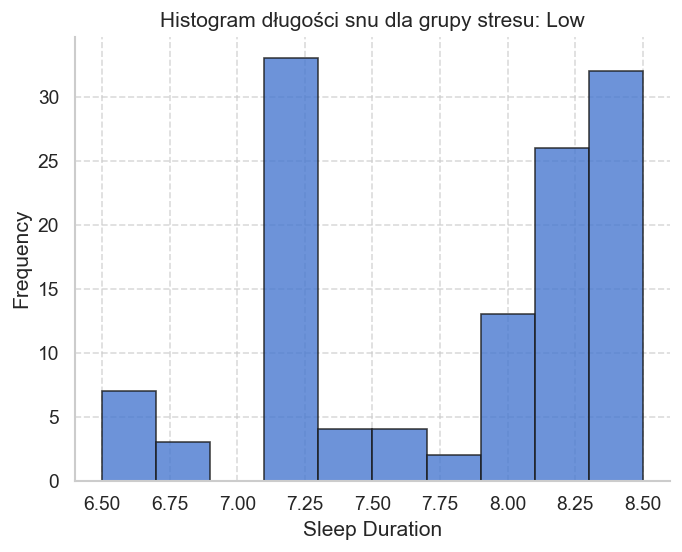

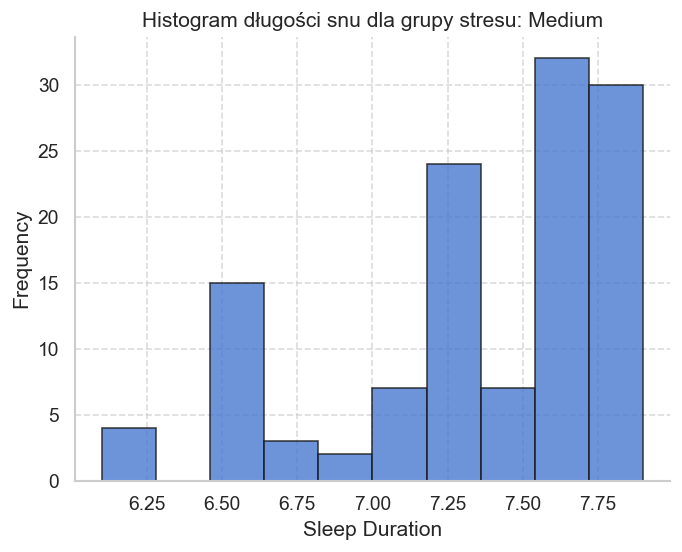

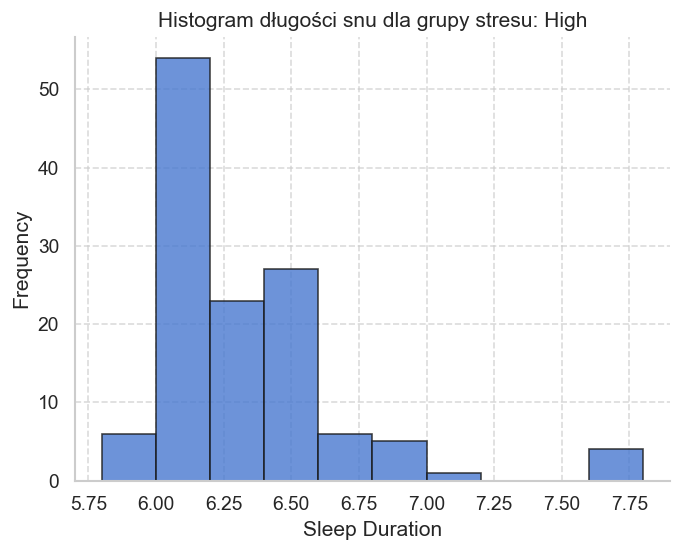

In [671]:
groups = data_anova['Stress_Level'].unique()

for group in groups:
    group_data = data_anova[data_anova['Stress_Level'] == group]['Sleep_Duration']
    plt.figure()
    plt.hist(group_data, bins=10, edgecolor='k', alpha=0.8)
    plt.title(f'Histogram długości snu dla grupy stresu: {group}')
    plt.xlabel('Sleep Duration')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

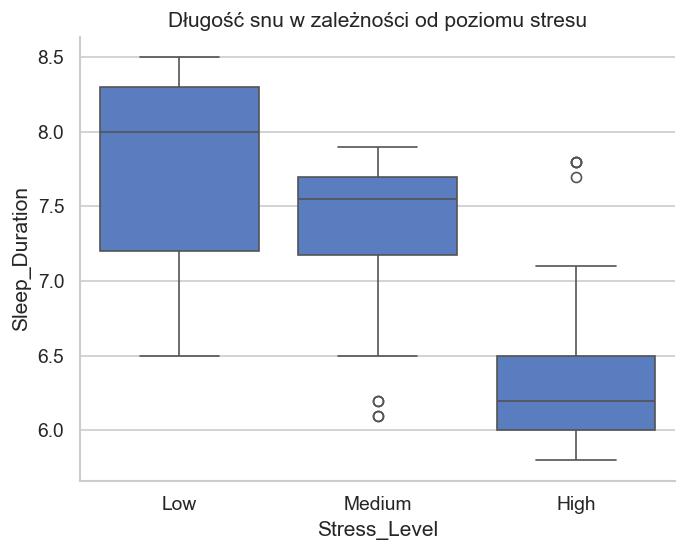

In [672]:
sns.boxplot(x='Stress_Level', y='Sleep_Duration', data=data_anova, order=['Low', 'Medium', 'High'])
plt.title('Długość snu w zależności od poziomu stresu')
plt.show()

### Weryfikacja założeń ANOVA dla wybranej pary

Zanim zinterpretujemy klasyczną ANOVA, sprawdzamy jej założenia dla pary stres → sen: **normalność** długości snu w każdej z trzech grup (test Shapiro-Wilka) oraz **jednorodność wariancji** (test Levene'a).

In [673]:
low = data_anova[data_anova.Stress_Level == 'Low']['Sleep_Duration']
medium = data_anova[data_anova.Stress_Level == 'Medium']['Sleep_Duration']
high = data_anova[data_anova.Stress_Level == 'High']['Sleep_Duration']

print("Normalność (test Shapiro-Wilka) w każdej grupie:")
for name, grp in [('Low', low), ('Medium', medium), ('High', high)]:
    w, p = shapiro(grp)
    print(f"  {name:7s}: W = {w:.3f}, p = {p:.4f}  ->  {'normalny' if p > 0.05 else 'NIE normalny'}")

print("\nJednorodność wariancji:")
lev_stat, lev_p = levene(low, medium, high)
print(f"  Test Levene'a:  statystyka = {lev_stat:.3f}, p = {lev_p:.4f}")

Normalność (test Shapiro-Wilka) w każdej grupie:
  Low    : W = 0.881, p = 0.0000  ->  NIE normalny
  Medium : W = 0.871, p = 0.0000  ->  NIE normalny
  High   : W = 0.777, p = 0.0000  ->  NIE normalny

Jednorodność wariancji:
  Test Levene'a:  statystyka = 19.018, p = 0.0000


Założenia klasycznej ANOVA **nie są spełnione**: w żadnej z trzech grup długość snu nie ma rozkładu normalnego (Shapiro-Wilk, p < 0,05), a wariancje grup różnią się istotnie (test Levene'a daje p < 0,05). To uzasadnia użycie testu Kruskal-Wallis obok klasycznej ANOVA.

### Klasyczna jednoczynnikowa ANOVA

In [674]:
model = ols('Sleep_Duration ~ C(Stress_Level)', data=data_anova).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print('Tabela ANOVA:')
print(anova_table)

PatsyError: Error evaluating factor: TypeError: 'int' object is not callable
    Sleep_Duration ~ C(Stress_Level)
                     ^^^^^^^^^^^^^^^

P-wartość jest znacznie mniejsza od 0,05, więc klasyczna ANOVA wskazuje na istotne różnice w długości snu między grupami. Ponieważ jej założenia są naruszone, wynik weryfikujemy poniżej testami odpornymi.

### Test Kruskala-Wallisa (nieparametryczny)

Test Kruskala-Wallisa to nieparametryczny odpowiednik ANOVA (uogólnienie testu Manna-Whitneya na >2 grupy). Działa na rangach, więc **nie wymaga normalności**.

In [ ]:
h_stat, p_value = kruskal(low, medium, high)
print("Test Kruskala-Wallisa:")
print(f"Statystyka H = {h_stat:.3f}")
print(f"P-wartość = {p_value:.4e}")

Również test Kruskala-Wallisa daje p < 0,05. **Oba podejścia (klasyczna ANOVA i Kruskal-Wallis) są zgodne** — różnice w długości snu między grupami poziomu stresu są istotne statystycznie, niezależnie od naruszenia założeń.

### Testy post hoc

ANOVA mówi tylko, że *gdzieś* istnieje różnica między grupami. Aby ustalić, które pary grup różnią się między sobą, stosujemy testy post hoc: parametryczny **test Tukeya** oraz nieparametryczny **parowy test Manna-Whitneya  (Wilcoxona) z poprawką Bonferroniego**.

In [ ]:
tukey_result = pairwise_tukeyhsd(endog=data_anova['Sleep_Duration'], groups=data_anova['Stress_Level'], alpha=0.05)
print('Wyniki testu post hoc (Tukey HSD):\n')
print(tukey_result)

In [ ]:
tukey_result.plot_simultaneous()
plt.show()

### Test post hoc nieparametryczny: parowy test Manna-Whitneya z poprawką Bonferroniego

Jako testy post host testu Kruskal-Wallis, wykonujemy parowe testy Manna-Whitneya (Wilcoxona) dla każdej pary grup, korygując p-wartości metodą Bonferroniego (mnożymy je przez liczbę porównań), aby kontrolować błąd przy wielokrotnym testowaniu.

In [ ]:
group_dict = {'Low': low, 'Medium': medium, 'High': high}
pairs = list(itertools.combinations(group_dict.keys(), 2))
n_comparisons = len(pairs)

print("Parowy test Wilcoxona (Manna-Whitneya) z poprawką Bonferroniego:\n")
for a, b in pairs:
    u_stat, p_raw = mannwhitneyu(group_dict[a], group_dict[b])
    p_bonf = min(p_raw * n_comparisons, 1.0)
    istotnosc = 'istotna' if p_bonf < 0.05 else 'nieistotna'
    print(f"{a:7s} vs {b:7s}: U = {u_stat:.1f}, p (Bonferroni) = {p_bonf:.4e}  ->  różnica {istotnosc}")

Oba testy post hoc — Tukeya i parowy Wilcoxona z poprawką Bonferroniego — są zgodne: **wszystkie trzy grupy różnią się między sobą** istotnie statystycznie. 

## Analiza regresji wielorakiej

### Analiza regresji wielorakiej zmiennej **Quality of Sleep**
W tej części zbudowaliśmy model regresji wielorakiej dla zmiennej **Quality of Sleep**. Jako zmienne objaśniające wzięliśmy cechy liczbowe oraz zakodowane zmienne binarne przygotowane wcześniej. Dzięki temu mogliśmy sprawdzić, które cechy najsilniej wpływają na jakość snu i jak dobrze model opisuje dane.


In [ ]:
regression_columns = [
    'Person ID',
    'Quality of Sleep',
    'Sleep Duration',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Age',
    'Systolic_BP',
    'Diastolic_BP',
    'Gender_binary',
    'BMI_binary'
]

regression_data = data[regression_columns].dropna().copy()
y_column = 'Quality of Sleep'
x_columns_full = [
    'Sleep Duration',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Age',
    'Systolic_BP',
    'Diastolic_BP',
    'Gender_binary',
    'BMI_binary'
]

print('Liczba obserwacji w analizie regresji:', len(regression_data))
print('Zmienna objaśniana:', y_column)
print('Zmienne objaśniające:', x_columns_full)

regression_data.head()


Liczba obserwacji w analizie regresji: 374
Zmienna objaśniana: Quality of Sleep
Zmienne objaśniające: ['Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Age', 'Systolic_BP', 'Diastolic_BP', 'Gender_binary', 'BMI_binary']


,Person ID,Quality of Sleep,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Age,Systolic_BP,Diastolic_BP,Gender_binary,BMI_binary
0,1,6,6.1,42,6,77,4200,27,126,83,1,1
1,2,6,6.2,60,8,75,10000,28,125,80,1,0
2,3,6,6.2,60,8,75,10000,28,125,80,1,0
3,4,4,5.9,30,8,85,3000,28,140,90,1,1
4,5,4,5.9,30,8,85,3000,28,140,90,1,1


In [ ]:
def compute_vif_from_df(df, predictor_names):
    X = df[predictor_names].to_numpy(dtype=float)
    vif_values = []
    for j, name in enumerate(predictor_names):
        other_idx = [i for i in range(len(predictor_names)) if i != j]
        y_j = X[:, j]
        X_other = X[:, other_idx]
        X_other = np.column_stack([np.ones(len(X_other)), X_other])
        beta, *_ = np.linalg.lstsq(X_other, y_j, rcond=None)
        y_hat = X_other @ beta
        ss_res = float(((y_j - y_hat) ** 2).sum())
        ss_tot = float(((y_j - y_j.mean()) ** 2).sum())
        r2_j = 1 - ss_res / ss_tot
        vif_values.append((name, 1 / (1 - r2_j)))
    return vif_values

vif_quality = compute_vif_from_df(regression_data, x_columns_full)
print('VIF dla kandydatów do modelu pełnego (Quality of Sleep):')
for name, vif in vif_quality:
    print(f'- {name}: VIF = {vif:.4f}')


VIF dla kandydatów do modelu pełnego (Quality of Sleep):
- Sleep Duration: VIF = 8.2181
- Physical Activity Level: VIF = 5.8814
- Stress Level: VIF = 8.1812
- Heart Rate: VIF = 3.9725
- Daily Steps: VIF = 6.8212
- Age: VIF = 7.4826
- Systolic_BP: VIF = 63.1813
- Diastolic_BP: VIF = 70.0028
- Gender_binary: VIF = 3.3676
- BMI_binary: VIF = 6.5751


**Wnioski z VIF:** W pierwszej analizie wyraźnie widać problem współliniowości. Najsilniejsza współliniowość dotyczy `Systolic_BP` i `Diastolic_BP`, bo ich VIF przekracza 60, więc obie zmienne niosą bardzo podobną informację. Podwyższone VIF mają też `Sleep Duration`, `Stress Level`, `Age`, `Daily Steps` i `BMI_binary'.


**Wnioski:** Do analizy wykorzystaliśmy 374 obserwacje. Zmienną objaśnianą jest jakość snu, a model startowy zawiera 10 potencjalnych zmiennych objaśniających.


### Wstępna ocena zależności między zmiennymi
Zanim zbudowaliśmy model, sprawdzaliśmy macierz korelacji. Pozwoliło nam to zobaczyć, które zmienne są najmocniej powiązane z jakością snu oraz czy między predyktorami mogą pojawić się zależności utrudniające interpretację modelu.


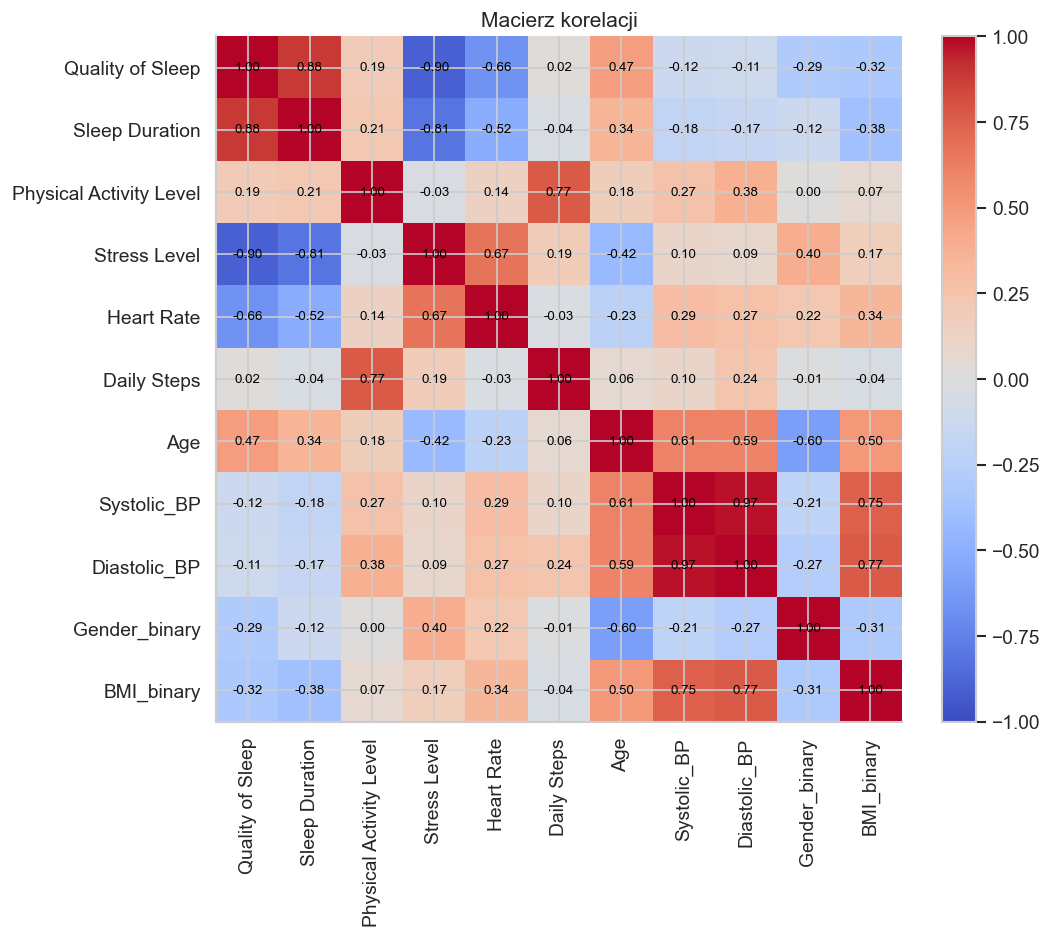

Quality of Sleep           1.000
Sleep Duration             0.883
Age                        0.474
Physical Activity Level    0.193
Daily Steps                0.017
Diastolic_BP              -0.110
Systolic_BP               -0.122
Gender_binary             -0.291
BMI_binary                -0.319
Heart Rate                -0.660
Stress Level              -0.899
Name: Quality of Sleep, dtype: float64

In [ ]:
correlation_matrix = regression_data.drop(columns=['Person ID']).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticklabels(correlation_matrix.columns)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Macierz korelacji')
plt.tight_layout()
plt.show()

correlation_matrix['Quality of Sleep'].sort_values(ascending=False).round(3)


**Wnioski:** Najsilniejsze związki z jakością snu widać dla poziomu stresu, tętna, wieku, BMI oraz czasu snu. Macierz korelacji pokazuje też, że część predyktorów jest ze sobą powiązana, więc warto później sprawdzić, które z nich pozostaną istotne w modelu wielorakim.


### Budowa pełnego modelu regresji wielorakiej
Najpierw zbudowaliśmy pełny model z wszystkimi przygotowanymi predyktorami. Korzystamy z klasycznej metody najmniejszych kwadratów i wyznaczamy współczynniki, błędy standardowe, statystyki t oraz p-value dla każdego parametru.


In [ ]:
y = regression_data[y_column].to_numpy(dtype=float)
X_full = regression_data[x_columns_full].to_numpy(dtype=float)
X_full = np.column_stack([np.ones(len(X_full)), X_full])
column_names_full = ['const'] + x_columns_full

XtX_full = X_full.T @ X_full
XtX_full_inv = np.linalg.inv(XtX_full)
beta_full = XtX_full_inv @ X_full.T @ y
y_hat_full = X_full @ beta_full
residuals_full = y - y_hat_full

n = len(y)
k_full = len(x_columns_full)

sse_full = residuals_full @ residuals_full
sst = ((y - y.mean()) @ (y - y.mean()))
ssr_full = sst - sse_full
mse_full = sse_full / (n - k_full - 1)
msr_full = ssr_full / k_full

r2_full = 1 - sse_full / sst
adj_r2_full = 1 - (1 - r2_full) * (n - 1) / (n - k_full - 1)
rmse_full = np.sqrt(np.mean(residuals_full ** 2))
residual_std_full = np.sqrt(mse_full)

standard_errors_full = np.sqrt(np.diag(mse_full * XtX_full_inv))
t_stats_full = beta_full / standard_errors_full
p_values_full = 2 * (1 - stats.t.cdf(np.abs(t_stats_full), df=n - k_full - 1))

F_full = msr_full / mse_full
F_full_p_value = 1 - stats.f.cdf(F_full, k_full, n - k_full - 1)

summary_full = pd.DataFrame({
    'Zmienna': column_names_full,
    'Współczynnik': beta_full,
    'Błąd standardowy': standard_errors_full,
    't': t_stats_full,
    'p-value': p_values_full
})

display(summary_full.round(4))
print(f'R^2 = {r2_full:.4f}')
print(f'Skorygowane R^2 = {adj_r2_full:.4f}')
print(f'RMSE = {rmse_full:.4f}')
print(f'Odchylenie standardowe reszt = {residual_std_full:.4f}')
print(f'Statystyka F = {F_full:.4f}')
print(f'p-value dla testu F = {F_full_p_value:.6f}')


,Zmienna,Współczynnik,Błąd standardowy,t,p-value
0,const,7.4565,0.7117,10.4774,0.0000
1,Sleep Duration,0.0933,0.0535,1.7429,0.0822
2,Physical Activity Level,0.0030,0.0017,1.7371,0.0832
3,Stress Level,-0.4510,0.0240,-18.8285,0.0000
4,Heart Rate,0.0057,0.0072,0.7889,0.4307
5,Daily Steps,0.0000,0.0000,1.1908,0.2345
6,Age,0.0619,0.0047,13.2064,0.0000
7,Systolic_BP,-0.0410,0.0152,-2.6878,0.0075
8,Diastolic_BP,0.0436,0.0202,2.1628,0.0312
9,Gender_binary,0.3351,0.0545,6.1517,0.0000


R^2 = 0.9440
Skorygowane R^2 = 0.9425
RMSE = 0.2828
Odchylenie standardowe reszt = 0.2870
Statystyka F = 612.4274
p-value dla testu F = 0.000000


**Wnioski:** Pełny model jest istotny jako całość i wyjaśnia około 94% zmienności jakości snu. Jednocześnie widać, że nie wszystkie predyktory są istotne statystycznie - szczególnie słabsze okazują się: czas snu, aktywność fizyczna, tętno oraz liczba kroków.


### Uproszczenie modelu i wybór wersji końcowej
Ponieważ część zmiennych w modelu pełnym nie jest istotna, budujemy prostszy model z predyktorami, które pozostały istotne statystycznie. Następnie porównujemy oba modele i wybieramy wersję końcową do dalszej analizy reszt.


In [ ]:
x_columns_final = [
    'Stress Level',
    'Age',
    'Systolic_BP',
    'Diastolic_BP',
    'Gender_binary',
    'BMI_binary'
]

X_final = regression_data[x_columns_final].to_numpy(dtype=float)
X_final = np.column_stack([np.ones(len(X_final)), X_final])
column_names_final = ['const'] + x_columns_final

XtX_final = X_final.T @ X_final
XtX_final_inv = np.linalg.inv(XtX_final)
beta_final = XtX_final_inv @ X_final.T @ y
y_hat_final = X_final @ beta_final
residuals_final = y - y_hat_final

k_final = len(x_columns_final)
sse_final = residuals_final @ residuals_final
ssr_final = sst - sse_final
mse_final = sse_final / (n - k_final - 1)
msr_final = ssr_final / k_final

r2_final = 1 - sse_final / sst
adj_r2_final = 1 - (1 - r2_final) * (n - 1) / (n - k_final - 1)
rmse_final = np.sqrt(np.mean(residuals_final ** 2))
residual_std_final = np.sqrt(mse_final)

standard_errors_final = np.sqrt(np.diag(mse_final * XtX_final_inv))
t_stats_final = beta_final / standard_errors_final
p_values_final = 2 * (1 - stats.t.cdf(np.abs(t_stats_final), df=n - k_final - 1))

F_final = msr_final / mse_final
F_final_p_value = 1 - stats.f.cdf(F_final, k_final, n - k_final - 1)

summary_final = pd.DataFrame({
    'Zmienna': column_names_final,
    'Współczynnik': beta_final,
    'Błąd standardowy': standard_errors_final,
    't': t_stats_final,
    'p-value': p_values_final
})

comparison = pd.DataFrame({
    'Model': ['Pełny', 'Uproszczony'],
    'Liczba predyktorów': [k_full, k_final],
    'R^2': [r2_full, r2_final],
    'Skorygowane R^2': [adj_r2_full, adj_r2_final],
    'RMSE': [rmse_full, rmse_final],
    'Odchylenie standardowe reszt': [residual_std_full, residual_std_final]
})

display(comparison.round(4))
display(summary_final.round(4))
print(f'Statystyka F dla modelu uproszczonego = {F_final:.4f}')
print(f'p-value dla testu F = {F_final_p_value:.6f}')


,Model,Liczba predyktorów,R^2,Skorygowane R^2,RMSE,Odchylenie standardowe reszt
0,Pełny,10,0.9440,0.9425,0.2828,0.2870
1,Uproszczony,6,0.9399,0.9390,0.2930,0.2957


,Zmienna,Współczynnik,Błąd standardowy,t,p-value
0,const,8.7177,0.3946,22.0930,0.0
1,Stress Level,-0.4603,0.0115,-40.1176,0.0
2,Age,0.0699,0.0033,21.4691,0.0
3,Systolic_BP,-0.0841,0.0094,-8.9003,0.0
4,Diastolic_BP,0.1081,0.0117,9.2446,0.0
5,Gender_binary,0.4386,0.0425,10.3148,0.0
6,BMI_binary,-1.0249,0.0512,-20.0044,0.0


Statystyka F dla modelu uproszczonego = 957.1255
p-value dla testu F = 0.000000


**Wnioski:** Model uproszczony ma minimalnie słabsze dopasowanie niż model pełny, ale nadal bardzo dobrze opisuje dane i jest łatwiejszy do interpretacji. Wszystkie pozostawione zmienne są istotne statystycznie, dlatego tę wersję przyjmuję jako model końcowy.


### Graficzna analiza reszt modelu końcowego
Po wyborze modelu końcowego sprawdzamy reszty. Interesują nas, czy są skupione wokół zera, czy nie widać wyraźnego wzorca oraz czy ich rozkład jest zbliżony do normalnego.


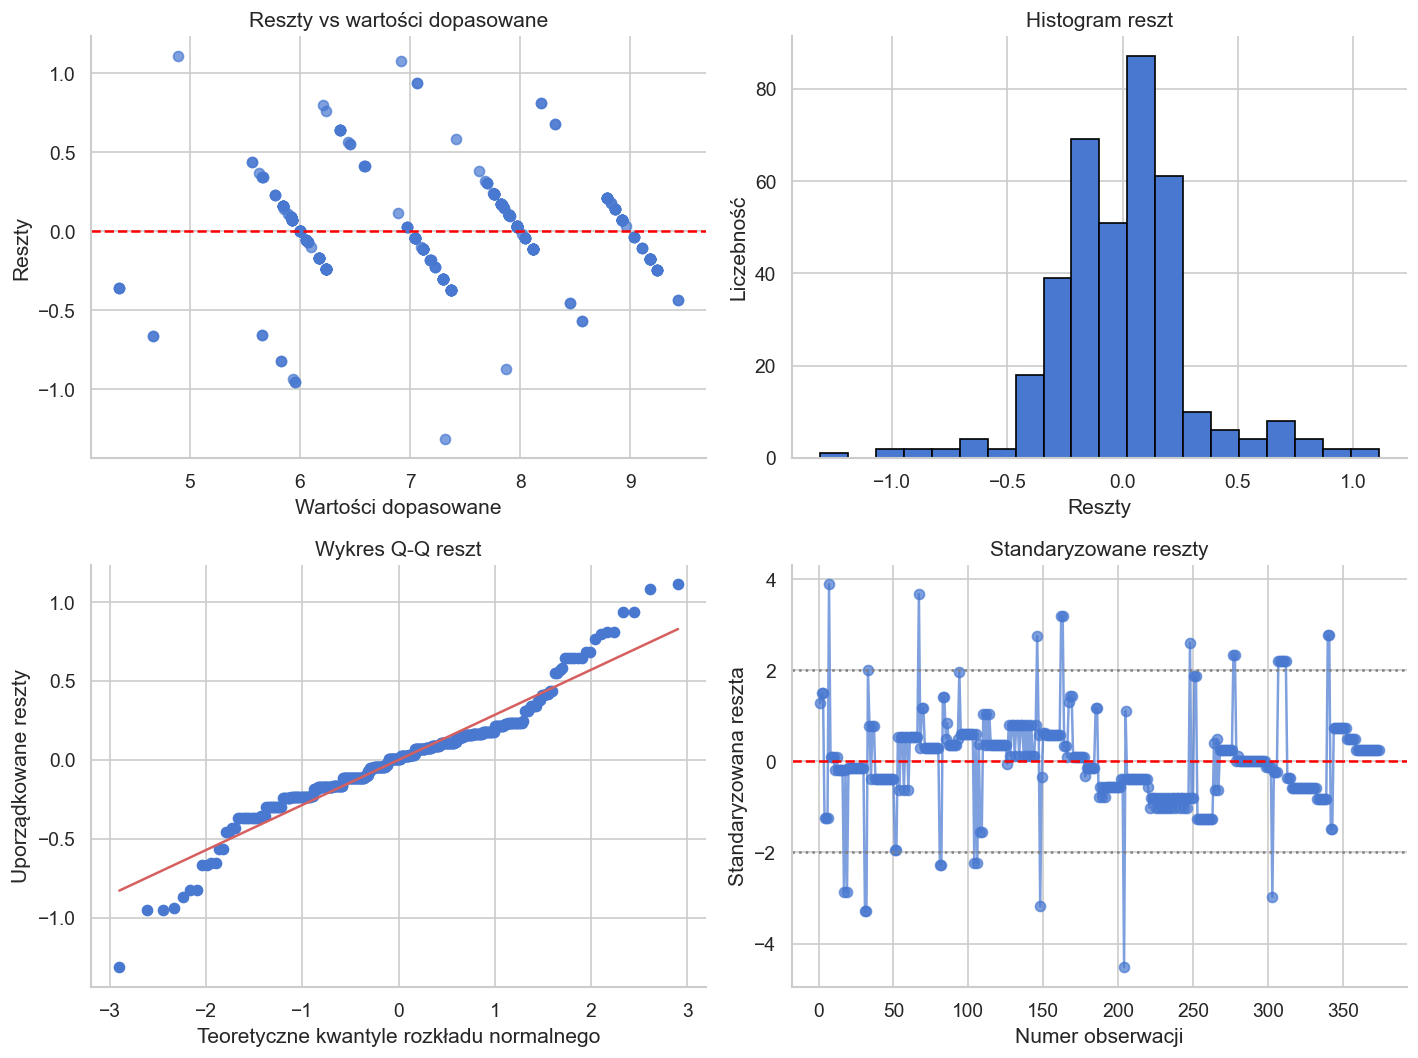

In [ ]:
leverages_final = np.sum((X_final @ XtX_final_inv) * X_final, axis=1)
standardized_residuals_final = residuals_final / np.sqrt(mse_final * (1 - leverages_final))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(y_hat_final, residuals_final, alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Reszty vs wartości dopasowane')
axes[0, 0].set_xlabel('Wartości dopasowane')
axes[0, 0].set_ylabel('Reszty')

axes[0, 1].hist(residuals_final, bins=20, edgecolor='black')
axes[0, 1].set_title('Histogram reszt')
axes[0, 1].set_xlabel('Reszty')
axes[0, 1].set_ylabel('Liczebność')

stats.probplot(residuals_final, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Wykres Q-Q reszt')
axes[1, 0].set_xlabel('Teoretyczne kwantyle rozkładu normalnego')
axes[1, 0].set_ylabel('Uporządkowane reszty')

axes[1, 1].plot(np.arange(1, n + 1), standardized_residuals_final, marker='o', linestyle='-', alpha=0.7)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].axhline(2, color='gray', linestyle=':')
axes[1, 1].axhline(-2, color='gray', linestyle=':')
axes[1, 1].set_title('Standaryzowane reszty')
axes[1, 1].set_xlabel('Numer obserwacji')
axes[1, 1].set_ylabel('Standaryzowana reszta')

plt.tight_layout()
plt.show()


**Wnioski:**  
- Reszty są rozłożone wokół zera, więc model nie jest całkowicie chybiony, ale istnieje jakis schemat tych reszt - widać ukośne ułożenie obserwacji.
- Na histogramie widać, że model jest bardzo podobny do rozkładu normalnego
- Wykres Q-Q - normalność reszt jest naruszona głównie na ogonach rozkładu
- Standaryzowane reszty - wiekszosc miesci sie w przedziale -2 do 2, ale są pojedyncze obserwacje przekraczające 2 lub poniżej -2 - więc istnieje kilka nietypowych obserwacji.


### Ocena reszt i obserwacji wpływowych
Na końcu wykonujemy kilka  miar diagnostycznych: test Shapiro-Wilka dla normalności reszt, statystykę Durbina-Watsona dla autokorelacji oraz odległość Cooka do wykrycia obserwacji wpływowych.


In [ ]:
shapiro_statistic, shapiro_p_value = stats.shapiro(residuals_final)
durbin_watson = np.sum(np.diff(residuals_final) ** 2) / np.sum(residuals_final ** 2)

cooks_distance = (residuals_final ** 2 / (X_final.shape[1] * mse_final)) * (leverages_final / (1 - leverages_final) ** 2)
cook_threshold = 4 / n

influence_table = regression_data[['Person ID']].copy()
influence_table['Wartość rzeczywista'] = y
influence_table['Wartość dopasowana'] = y_hat_final
influence_table['Reszta'] = residuals_final
influence_table['Standaryzowana reszta'] = standardized_residuals_final
influence_table['Cook distance'] = cooks_distance

top_influential = influence_table.sort_values('Cook distance', ascending=False).head(10)

print(f'Test Shapiro-Wilka: statystyka = {shapiro_statistic:.4f}, p-value = {shapiro_p_value:.6f}')
print(f'Statystyka Durbina-Watsona = {durbin_watson:.4f}')
print(f'Próg 4/n dla odległości Cooka = {cook_threshold:.6f}')
print('Liczba obserwacji z Cook distance > 4/n:', (cooks_distance > cook_threshold).sum())

display(top_influential.round(4))


Test Shapiro-Wilka: statystyka = 0.9392, p-value = 0.000000
Statystyka Durbina-Watsona = 1.2323
Próg 4/n dla odległości Cooka = 0.010695
Liczba obserwacji z Cook distance > 4/n: 36


,Person ID,Wartość rzeczywista,Wartość dopasowana,Reszta,Standaryzowana reszta,Cook distance
6,7,6.0,4.8881,1.1119,3.8852,0.1463
203,204,6.0,7.3134,-1.3134,-4.5229,0.1089
31,32,5.0,5.9530,-0.9530,-3.2948,0.0704
30,31,5.0,5.9530,-0.9530,-3.2948,0.0704
18,19,5.0,5.8230,-0.8230,-2.8622,0.0679
16,17,5.0,5.8230,-0.8230,-2.8622,0.0679
145,146,7.0,6.2038,0.7962,2.7435,0.0414
302,303,7.0,7.8700,-0.8700,-2.9800,0.0333
276,277,9.0,8.3200,0.6800,2.3381,0.0265
277,278,9.0,8.3200,0.6800,2.3381,0.0265


**Wnioski:** 

* Wyniki diagnostyki wskazują, że model nie spełnia w pełni klasycznych założeń regresji liniowej. Test Shapiro-Wilka dał statystykę równą 0.9392 oraz p-value < 0.001, co oznacza, że należy odrzucić hipotezę zerową o normalności reszt. Reszty modelu istotnie odbiegają więc od rozkładu normalnego.
* Statystyka Durbina-Watsona wynosi 1.2323. Wartość ta jest niższa od 2, co sugeruje występowanie dodatniej autokorelacji reszt, choć nie tak silnej jak przy wartościach bliskich 0. Oznacza to, że reszty mogą nie być w pełni niezależne, a w danych może występować pewna struktura niewyjaśniona przez model.
* Próg dla odległości Cooka wynosi 0.010695, a liczba obserwacji przekraczających ten próg to 36. Oznacza to, że w zbiorze znajduje się stosunkowo dużo obserwacji wpływowych, które mogą istotnie oddziaływać na wartości współczynników regresji. Takie obserwacje warto dokładniej przeanalizować, ponieważ mogą być nietypowe, odstające albo mieć duże znaczenie dla dopasowania modelu.


### Analiza regresji wielorakiej zmiennej **Sleep Duration**
Jako drugą zmienną objaśnianą wybieraym **Sleep Duration**. Jest to zmienna ciągła i jednocześnie bardzo naturalnie wiąże się z pozostałymi cechami zdrowotnymi oraz stylem życia, więc dobrze nadaje się do kolejnej analizy regresji wielorakiej.


In [ ]:
sleep_duration_columns = [
    'Person ID',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Age',
    'Systolic_BP',
    'Diastolic_BP',
    'Gender_binary',
    'BMI_binary'
]

sleep_duration_data = data[sleep_duration_columns].dropna().copy()
y_column_sleep = 'Sleep Duration'
x_columns_sleep_full = [
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Heart Rate',
    'Daily Steps',
    'Age',
    'Systolic_BP',
    'Diastolic_BP',
    'Gender_binary',
    'BMI_binary'
]

print('Liczba obserwacji w drugiej analizie regresji:', len(sleep_duration_data))
print('Zmienna objaśniana:', y_column_sleep)
print('Zmienne objaśniające:', x_columns_sleep_full)

sleep_duration_data.head()


Liczba obserwacji w drugiej analizie regresji: 374
Zmienna objaśniana: Sleep Duration
Zmienne objaśniające: ['Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Age', 'Systolic_BP', 'Diastolic_BP', 'Gender_binary', 'BMI_binary']


,Person ID,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Age,Systolic_BP,Diastolic_BP,Gender_binary,BMI_binary
0,1,6.1,6,42,6,77,4200,27,126,83,1,1
1,2,6.2,6,60,8,75,10000,28,125,80,1,0
2,3,6.2,6,60,8,75,10000,28,125,80,1,0
3,4,5.9,4,30,8,85,3000,28,140,90,1,1
4,5,5.9,4,30,8,85,3000,28,140,90,1,1


In [ ]:
vif_sleep_duration = compute_vif_from_df(sleep_duration_data, x_columns_sleep_full)
print('VIF dla kandydatów do modelu pełnego (Sleep Duration):')
for name, vif in vif_sleep_duration:
    print(f'- {name}: VIF = {vif:.4f}')


VIF dla kandydatów do modelu pełnego (Sleep Duration):
- Quality of Sleep: VIF = 17.7230
- Physical Activity Level: VIF = 5.7524
- Stress Level: VIF = 13.6860
- Heart Rate: VIF = 3.7368
- Daily Steps: VIF = 6.2945
- Age: VIF = 8.4504
- Systolic_BP: VIF = 51.8737
- Diastolic_BP: VIF = 59.0645
- Gender_binary: VIF = 2.7893
- BMI_binary: VIF = 6.6936


**Wnioski z VIF:** W drugiej analizie współliniowość jest jeszcze silniejsza. Bardzo wysokie wartości VIF mają `Systolic_BP` i `Diastolic_BP`, a dodatkowo wysoki VIF pojawia się też dla `Quality of Sleep` oraz `Stress Level`.


**Wnioski:** W drugiej analizie badamy długość snu. W modelu startowym wykorzystujemy 10 zmiennych objaśniających, aby sprawdzić, które cechy najlepiej tłumaczą zróżnicowanie czasu snu.


### Korelacje dla modelu z długością snu
Przed dopasowaniem modelu sprawdzamy korelacje między zmiennymi. Pozwala to zobaczyć, które cechy są najbardziej związane z długością snu i czy między predyktorami może występować współliniowość.


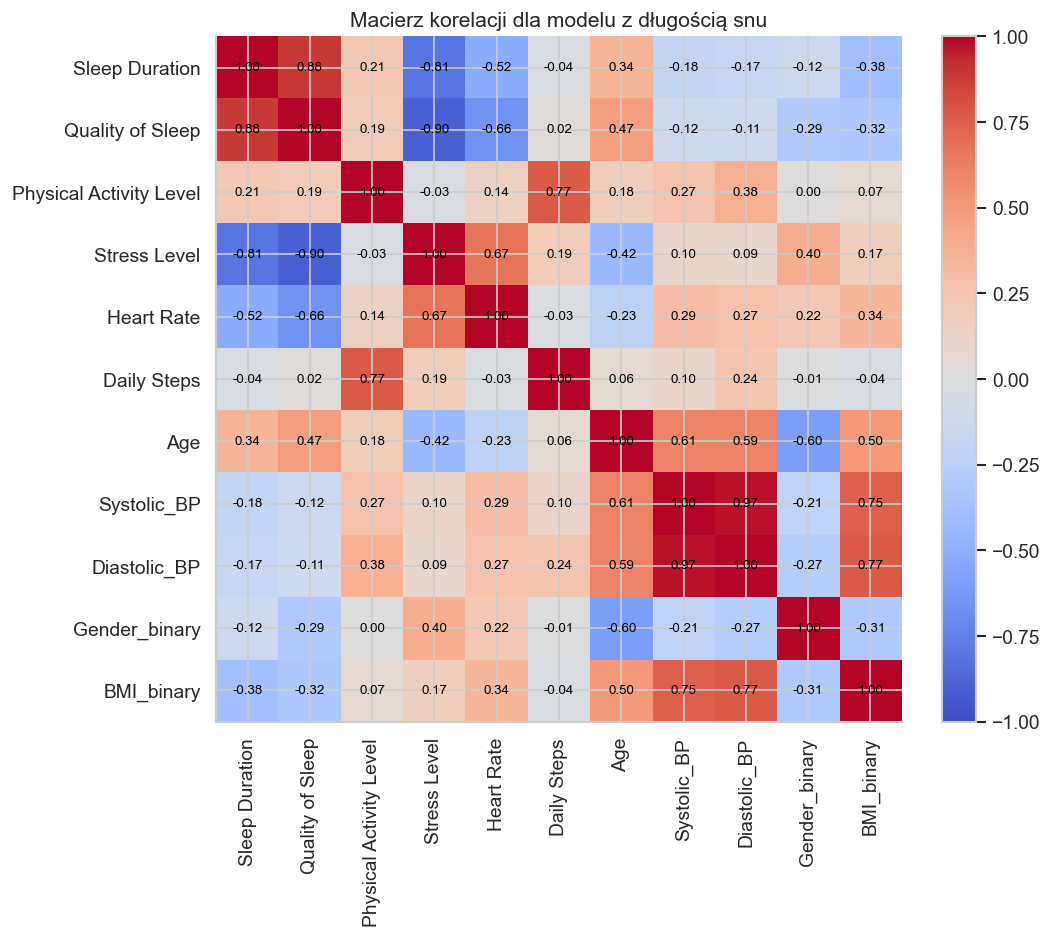

Sleep Duration             1.000
Quality of Sleep           0.883
Age                        0.345
Physical Activity Level    0.212
Daily Steps               -0.040
Gender_binary             -0.122
Diastolic_BP              -0.167
Systolic_BP               -0.180
BMI_binary                -0.377
Heart Rate                -0.516
Stress Level              -0.811
Name: Sleep Duration, dtype: float64

In [ ]:
correlation_matrix_sleep = sleep_duration_data.drop(columns=['Person ID']).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix_sleep, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_matrix_sleep.columns)))
ax.set_yticks(range(len(correlation_matrix_sleep.columns)))
ax.set_xticklabels(correlation_matrix_sleep.columns, rotation=90)
ax.set_yticklabels(correlation_matrix_sleep.columns)

for i in range(len(correlation_matrix_sleep.index)):
    for j in range(len(correlation_matrix_sleep.columns)):
        ax.text(j, i, f"{correlation_matrix_sleep.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Macierz korelacji dla modelu z długością snu')
plt.tight_layout()
plt.show()

correlation_matrix_sleep['Sleep Duration'].sort_values(ascending=False).round(3)


**Wnioski:** Długość snu jest wyraźnie związana między innymi z jakością snu, poziomem stresu oraz wiekiem. W macierzy korelacji widać też zależności między niektórymi predyktorami, dlatego przy interpretacji współczynników trzeba brać pod uwagę wpływ pozostałych zmiennych.


### Pełny model regresji dla długości snu
Najpierw dopasowujemy pełny model z wszystkimi przygotowanymi predyktorami. Obliczamy współczynniki regresji, błędy standardowe, statystyki t oraz p-value, a następnie oceniamy jakość dopasowania całego modelu.


In [ ]:
y_sleep = sleep_duration_data[y_column_sleep].to_numpy(dtype=float)
X_sleep_full = sleep_duration_data[x_columns_sleep_full].to_numpy(dtype=float)
X_sleep_full = np.column_stack([np.ones(len(X_sleep_full)), X_sleep_full])
column_names_sleep_full = ['const'] + x_columns_sleep_full

XtX_sleep_full = X_sleep_full.T @ X_sleep_full
XtX_sleep_full_inv = np.linalg.inv(XtX_sleep_full)
beta_sleep_full = XtX_sleep_full_inv @ X_sleep_full.T @ y_sleep
y_hat_sleep_full = X_sleep_full @ beta_sleep_full
residuals_sleep_full = y_sleep - y_hat_sleep_full

n_sleep = len(y_sleep)
k_sleep_full = len(x_columns_sleep_full)

sse_sleep_full = residuals_sleep_full @ residuals_sleep_full
sst_sleep = ((y_sleep - y_sleep.mean()) @ (y_sleep - y_sleep.mean()))
ssr_sleep_full = sst_sleep - sse_sleep_full
mse_sleep_full = sse_sleep_full / (n_sleep - k_sleep_full - 1)
msr_sleep_full = ssr_sleep_full / k_sleep_full

r2_sleep_full = 1 - sse_sleep_full / sst_sleep
adj_r2_sleep_full = 1 - (1 - r2_sleep_full) * (n_sleep - 1) / (n_sleep - k_sleep_full - 1)
rmse_sleep_full = np.sqrt(np.mean(residuals_sleep_full ** 2))
residual_std_sleep_full = np.sqrt(mse_sleep_full)

standard_errors_sleep_full = np.sqrt(np.diag(mse_sleep_full * XtX_sleep_full_inv))
t_stats_sleep_full = beta_sleep_full / standard_errors_sleep_full
p_values_sleep_full = 2 * (1 - stats.t.cdf(np.abs(t_stats_sleep_full), df=n_sleep - k_sleep_full - 1))

F_sleep_full = msr_sleep_full / mse_sleep_full
F_sleep_full_p_value = 1 - stats.f.cdf(F_sleep_full, k_sleep_full, n_sleep - k_sleep_full - 1)

summary_sleep_full = pd.DataFrame({
    'Zmienna': column_names_sleep_full,
    'Współczynnik': beta_sleep_full,
    'Błąd standardowy': standard_errors_sleep_full,
    't': t_stats_sleep_full,
    'p-value': p_values_sleep_full
})

display(summary_sleep_full.round(4))
print(f'R^2 = {r2_sleep_full:.4f}')
print(f'Skorygowane R^2 = {adj_r2_sleep_full:.4f}')
print(f'RMSE = {rmse_sleep_full:.4f}')
print(f'Odchylenie standardowe reszt = {residual_std_sleep_full:.4f}')
print(f'Statystyka F = {F_sleep_full:.4f}')
print(f'p-value dla testu F = {F_sleep_full_p_value:.6f}')


,Zmienna,Współczynnik,Błąd standardowy,t,p-value
0,const,7.1102,0.6995,10.1644,0.0000
1,Quality of Sleep,0.0889,0.0510,1.7429,0.0822
2,Physical Activity Level,0.0056,0.0017,3.3501,0.0009
3,Stress Level,-0.2455,0.0302,-8.1188,0.0000
4,Heart Rate,0.0329,0.0068,4.8532,0.0000
5,Daily Steps,-0.0001,0.0000,-5.6491,0.0000
6,Age,0.0517,0.0049,10.6235,0.0000
7,Systolic_BP,-0.1264,0.0135,-9.3769,0.0000
8,Diastolic_BP,0.1544,0.0181,8.5305,0.0000
9,Gender_binary,0.5322,0.0484,10.9978,0.0000


R^2 = 0.8793
Skorygowane R^2 = 0.8760
RMSE = 0.2760
Odchylenie standardowe reszt = 0.2802
Statystyka F = 264.5145
p-value dla testu F = 0.000000


**Wnioski:** Pełny model dla długości snu jest istotny statystycznie i dobrze opisuje dane, ale nie wszystkie zmienne mają równie ważny wkład. Dlatego w następnym kroku upraszczamy model i zostawiamy tylko te predyktory, które są najłatwiejsze do obrony interpretacyjnej.


### Uproszczony model regresji dla długości snu
Na podstawie wyników modelu pełnego budujemy model prostszy, pozostawiając tylko zmienne istotne statystycznie. Dzięki temu model końcowy jest bardziej przejrzysty, a spadek jakości dopasowania można łatwo porównać z wersją pełną.


In [ ]:
x_columns_sleep_final = [
    'Quality of Sleep',
    'Stress Level',
    'Age',
    'Systolic_BP',
    'Diastolic_BP',
    'Gender_binary',
    'BMI_binary'
]

X_sleep_final = sleep_duration_data[x_columns_sleep_final].to_numpy(dtype=float)
X_sleep_final = np.column_stack([np.ones(len(X_sleep_final)), X_sleep_final])
column_names_sleep_final = ['const'] + x_columns_sleep_final

XtX_sleep_final = X_sleep_final.T @ X_sleep_final
XtX_sleep_final_inv = np.linalg.inv(XtX_sleep_final)
beta_sleep_final = XtX_sleep_final_inv @ X_sleep_final.T @ y_sleep
y_hat_sleep_final = X_sleep_final @ beta_sleep_final
residuals_sleep_final = y_sleep - y_hat_sleep_final

k_sleep_final = len(x_columns_sleep_final)
sse_sleep_final = residuals_sleep_final @ residuals_sleep_final
ssr_sleep_final = sst_sleep - sse_sleep_final
mse_sleep_final = sse_sleep_final / (n_sleep - k_sleep_final - 1)
msr_sleep_final = ssr_sleep_final / k_sleep_final

r2_sleep_final = 1 - sse_sleep_final / sst_sleep
adj_r2_sleep_final = 1 - (1 - r2_sleep_final) * (n_sleep - 1) / (n_sleep - k_sleep_final - 1)
rmse_sleep_final = np.sqrt(np.mean(residuals_sleep_final ** 2))
residual_std_sleep_final = np.sqrt(mse_sleep_final)

standard_errors_sleep_final = np.sqrt(np.diag(mse_sleep_final * XtX_sleep_final_inv))
t_stats_sleep_final = beta_sleep_final / standard_errors_sleep_final
p_values_sleep_final = 2 * (1 - stats.t.cdf(np.abs(t_stats_sleep_final), df=n_sleep - k_sleep_final - 1))

F_sleep_final = msr_sleep_final / mse_sleep_final
F_sleep_final_p_value = 1 - stats.f.cdf(F_sleep_final, k_sleep_final, n_sleep - k_sleep_final - 1)

summary_sleep_final = pd.DataFrame({
    'Zmienna': column_names_sleep_final,
    'Współczynnik': beta_sleep_final,
    'Błąd standardowy': standard_errors_sleep_final,
    't': t_stats_sleep_final,
    'p-value': p_values_sleep_final
})

comparison_sleep = pd.DataFrame({
    'Model': ['Pełny', 'Uproszczony'],
    'Liczba predyktorów': [k_sleep_full, k_sleep_final],
    'R^2': [r2_sleep_full, r2_sleep_final],
    'Skorygowane R^2': [adj_r2_sleep_full, adj_r2_sleep_final],
    'RMSE': [rmse_sleep_full, rmse_sleep_final],
    'Odchylenie standardowe reszt': [residual_std_sleep_full, residual_std_sleep_final]
})

display(comparison_sleep.round(4))
display(summary_sleep_final.round(4))
print(f'Statystyka F dla modelu uproszczonego = {F_sleep_final:.4f}')
print(f'p-value dla testu F = {F_sleep_final_p_value:.6f}')


,Model,Liczba predyktorów,R^2,Skorygowane R^2,RMSE,Odchylenie standardowe reszt
0,Pełny,10,0.8793,0.8760,0.276,0.2802
1,Uproszczony,7,0.8368,0.8337,0.321,0.3245


,Zmienna,Współczynnik,Błąd standardowy,t,p-value
0,const,7.4284,0.6608,11.2411,0.0000
1,Quality of Sleep,0.1369,0.0573,2.3903,0.0173
2,Stress Level,-0.2335,0.0292,-7.9909,0.0000
3,Age,0.0359,0.0054,6.6862,0.0000
4,Systolic_BP,-0.0678,0.0114,-5.9287,0.0000
5,Diastolic_BP,0.0843,0.0142,5.9195,0.0000
6,Gender_binary,0.4931,0.0530,9.3064,0.0000
7,BMI_binary,-0.5349,0.0813,-6.5821,0.0000


Statystyka F dla modelu uproszczonego = 268.1116
p-value dla testu F = 0.000000


**Wnioski:** Model uproszczony nadal dobrze opisuje długość snu, a przy tym jest bardziej czytelny. W praktyce taka wersja jest wygodniejsza do prezentacji, bo łatwiej wskazać najważniejsze czynniki wpływające na czas snu.


### Analiza reszt modelu końcowego dla długości snu
Po wyborze modelu końcowego sprawdzamy reszty: czy są skupione wokół zera, czy rozkład jest zbliżony do normalnego i czy nie pojawiają się obserwacje wyraźnie odstające.


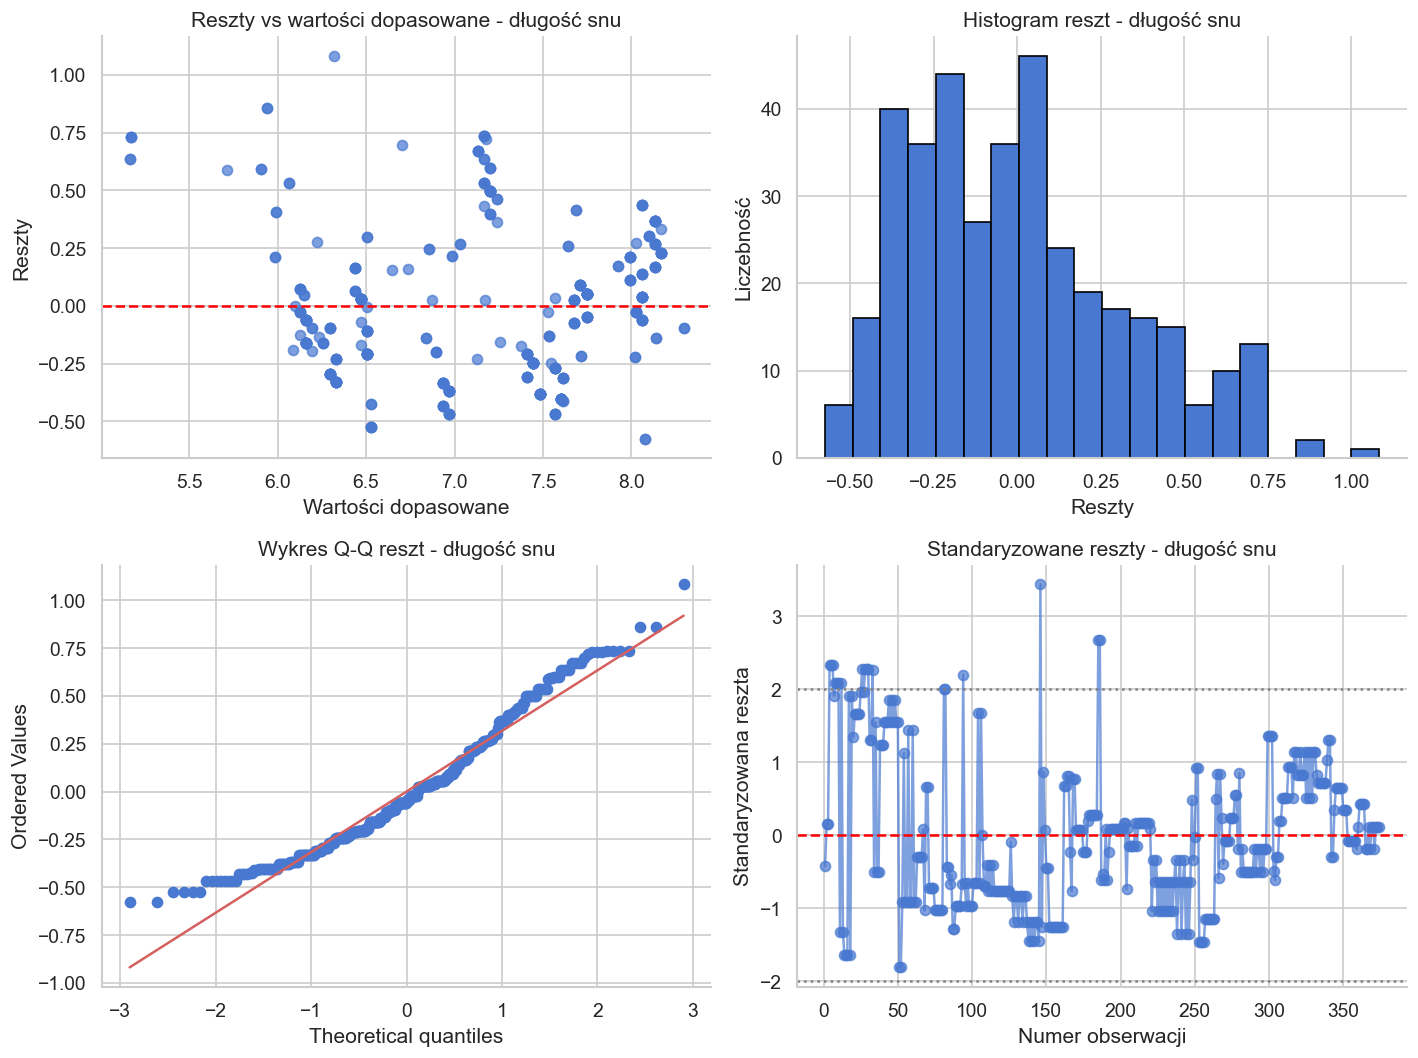

In [ ]:
leverages_sleep_final = np.sum((X_sleep_final @ XtX_sleep_final_inv) * X_sleep_final, axis=1)
standardized_residuals_sleep_final = residuals_sleep_final / np.sqrt(mse_sleep_final * (1 - leverages_sleep_final))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(y_hat_sleep_final, residuals_sleep_final, alpha=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Reszty vs wartości dopasowane - długość snu')
axes[0, 0].set_xlabel('Wartości dopasowane')
axes[0, 0].set_ylabel('Reszty')

axes[0, 1].hist(residuals_sleep_final, bins=20, edgecolor='black')
axes[0, 1].set_title('Histogram reszt - długość snu')
axes[0, 1].set_xlabel('Reszty')
axes[0, 1].set_ylabel('Liczebność')

stats.probplot(residuals_sleep_final, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Wykres Q-Q reszt - długość snu')

axes[1, 1].plot(np.arange(1, n_sleep + 1), standardized_residuals_sleep_final, marker='o', linestyle='-', alpha=0.7)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].axhline(2, color='gray', linestyle=':')
axes[1, 1].axhline(-2, color='gray', linestyle=':')
axes[1, 1].set_title('Standaryzowane reszty - długość snu')
axes[1, 1].set_xlabel('Numer obserwacji')
axes[1, 1].set_ylabel('Standaryzowana reszta')

plt.tight_layout()
plt.show()


**Wnioski:**  
- Reszty są rozłożone wokół zera, więc model nie jest całkowicie chybiony - chociaz widać pewne skupiska, więc rozkład nie jest idealnie losowy
- Na histogramie widać asymetrie prawostronną, więc rozkład nie jest idealnie normalny
- Wykres Q-Q reszt tak jak poprzednio - normalność reszt jest naruszona głównie na ogonach rozkładu
- Standaryzowane reszty - wiekszosc miesci sie w przedziale -2 do 2, ale są pojedyncze obserwacje przekraczające 2 - więc istnieje kilka nietypowych obserwacji.


### Ocena reszt i obserwacji wpływowych
Na końcu obliczamy test Shapiro-Wilka, statystykę Durbina-Watsona oraz odległości Cooka.


In [ ]:
shapiro_sleep_statistic, shapiro_sleep_p_value = stats.shapiro(residuals_sleep_final)
durbin_watson_sleep = np.sum(np.diff(residuals_sleep_final) ** 2) / np.sum(residuals_sleep_final ** 2)

cooks_distance_sleep = (residuals_sleep_final ** 2 / (X_sleep_final.shape[1] * mse_sleep_final)) * (leverages_sleep_final / (1 - leverages_sleep_final) ** 2)
cook_sleep_threshold = 4 / n_sleep

influence_sleep_table = sleep_duration_data[['Person ID']].copy()
influence_sleep_table['Wartość rzeczywista'] = y_sleep
influence_sleep_table['Wartość dopasowana'] = y_hat_sleep_final
influence_sleep_table['Reszta'] = residuals_sleep_final
influence_sleep_table['Standaryzowana reszta'] = standardized_residuals_sleep_final
influence_sleep_table['Cook distance'] = cooks_distance_sleep

top_influential_sleep = influence_sleep_table.sort_values('Cook distance', ascending=False).head(10)

print(f'Test Shapiro-Wilka: statystyka = {shapiro_sleep_statistic:.4f}, p-value = {shapiro_sleep_p_value:.6f}')
print(f'Statystyka Durbina-Watsona = {durbin_watson_sleep:.4f}')
print(f'Próg 4/n dla odległości Cooka = {cook_sleep_threshold:.6f}')
print('Liczba obserwacji z Cook distance > 4/n:', (cooks_distance_sleep > cook_sleep_threshold).sum())

display(top_influential_sleep.round(4))


Test Shapiro-Wilka: statystyka = 0.9591, p-value = 0.000000
Statystyka Durbina-Watsona = 0.8746
Próg 4/n dla odległości Cooka = 0.010695
Liczba obserwacji z Cook distance > 4/n: 19


,Person ID,Wartość rzeczywista,Wartość dopasowana,Reszta,Standaryzowana reszta,Cook distance
145,146,7.4,6.3163,1.0837,3.4388,0.0890
6,7,6.3,5.7124,0.5876,1.9110,0.0519
3,4,5.9,5.1693,0.7307,2.3306,0.0483
4,5,5.9,5.1693,0.7307,2.3306,0.0483
5,6,5.9,5.1693,0.7307,2.3306,0.0483
16,17,6.5,5.9066,0.5934,1.9023,0.0372
18,19,6.5,5.9066,0.5934,1.9023,0.0372
93,94,7.4,6.7018,0.6982,2.1991,0.0269
80,81,5.8,5.1643,0.6357,2.0054,0.0240
81,82,5.8,5.1643,0.6357,2.0054,0.0240


**Wnioski:** 
* Podobne jak dla jakości snu, z tą różnicą, że autokorelacja jest bardziej dodatnia (0.8746 < 1.2323 < 2.0), ale istnieje mniej obserwacji wpływowych


## Podsumowanie regresji wielorakiej
### Analizowany model regresji wielorakiej nie spełnia w pełni założen omawianych na wykładzie.
* wystepuję dodatnia autokorelacja reszt
* test Shapiro-Wilka odrzuca normalność reszt
* wykres reszt suigeruje brak pełnej losowości
* odległość Cooka wskazuje na obecność obserwacji wpływowych
  
Dlatego model moze byc użyteczny opisowo (model da się policzyć), ale trzeba go ostrożnie interpretować, bo nie spełnia założeń teorii regresji.

<h1>Import bibliotek</h1>

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import kstest

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

<H1>Parametry modelu</H1>

In [ ]:
LAMBDA = 3.0             # Intensywność przybywania klientów
MU = 1.2                 # Intensywność obsługi jednej kasy
C = 3                    # Liczba kas
N_CUSTOMERS = 5000       # Liczba klientów
SEED = 42                # Ziarno generatora losowego
N_RUNS = 25              # Ilość replikacji
RHO = LAMBDA / (C * MU)  # Współczynnik wykorzystania systemu

<h1>Symulacja M/M/c</h1>

In [ ]:
def run_simulation(lam, mu, c, n_customers, seed=42):
    rng = np.random.default_rng(seed)

    events = []
    event_times = []

    def push_event(t, etype, cid):
        events.append((t, etype, cid))
        events.sort(key=lambda x: x[0])
        event_times.append(t)

    servers_free = c
    queue = []

    wait_times = []
    queue_lengths = []

    current_time = 0.0
    cid_counter = 0
    served = 0

    t0 = rng.exponential(1 / lam)
    push_event(t0, "ARRIVAL", cid_counter)
    cid_counter += 1

    while events and served < n_customers:
        t, etype, cid = events.pop(0)
        current_time = t

        if etype == "ARRIVAL":
            queue_lengths.append(len(queue))

            if servers_free > 0:
                servers_free -= 1
                wait_times.append(0.0)
                svc = rng.exponential(1 / mu)
                push_event(current_time + svc, "DEPARTURE", cid)
            else:
                queue.append((current_time, cid))

            if cid_counter < n_customers:
                t_next = current_time + rng.exponential(1 / lam)
                push_event(t_next, "ARRIVAL", cid_counter)
                cid_counter += 1

        else:
            served += 1

            if queue:
                arr_t, next_cid = queue.pop(0)
                wait_times.append(current_time - arr_t)
                svc = rng.exponential(1 / mu)
                push_event(current_time + svc, "DEPARTURE", next_cid)
            else:
                servers_free += 1

    return {
        "wait_times": np.array(wait_times),
        "queue_lengths": np.array(queue_lengths),
        "event_times": np.array(event_times)
    }

<h1>Wartości teoretyczne - wzór Erlanga C (do walidacji systemu)</h1>

In [ ]:
def erlang_c(lam, mu, c):
    a     = lam / mu      
    rho_c = a / c
    if rho_c >= 1:
        raise ValueError(f"System niestabilny: ρ = {rho_c:.3f} ≥ 1")
    fac, s = 1, 1.0
    for k in range(1, c):
        fac *= k
        s   += a**k / fac
    fac *= c
    last  = a**c / (fac * (1 - rho_c))
    C_erl = last / (s + last)           # P(W_q > 0)
    Wq    = C_erl / (c * mu * (1 - rho_c))
    W     = Wq + 1 / mu
    Lq    = lam * Wq
    L     = lam * W
    return dict(C_erl=C_erl, Wq=Wq, W=W, Lq=Lq, L=L)

theory = erlang_c(LAMBDA, MU, C)

print(f"{'-'*80}")
print(f"  Prawdopodobieństwo oczekiwania klientów w kolejece:")
print(f"  Erlang C  P(W_q>0) = {theory['C_erl']:.4f}")
print(f"  Średni czas oczekiwania w kolejce:")
print(f"  E[W_q]  (teoria)   = {theory['Wq']:.4f} min")
print(f"  Średni czas całkowitej osbługi klienta (czas w kolejce + czas obsługi):")
print(f"  E[W]    (teoria)   = {theory['W']:.4f} min")
print(f"  Średnia długość kolejki:")
print(f"  E[L_q]  (teoria)   = {theory['Lq']:.4f} klientów")
print(f"  Średnia liczba klientów w systemie (osoby w kolejce + osoby obsługiwane):")
print(f"  E[L]    (teoria)   = {theory['L']:.4f} klientów")
print(f"{'-'*80}")

--------------------------------------------------------------------------------
  Prawdopodobieństwo oczekiwania klientów w kolejece:
  Erlang C  P(W_q>0) = 0.7022
  Średni czas oczekiwania w kolejce:
  E[W_q]  (teoria)   = 1.1704 min
  Średni czas całkowitej osbługi klienta (czas w kolejce + czas obsługi):
  E[W]    (teoria)   = 2.0037 min
  Średnia długość kolejki:
  E[L_q]  (teoria)   = 3.5112 klientów
  Średnia liczba klientów w systemie (osoby w kolejce + osoby obsługiwane):
  E[L]    (teoria)   = 6.0112 klientów
--------------------------------------------------------------------------------


<h1>Analiza statystyczna</h1>

In [ ]:
run_results = []
for i in range(N_RUNS):
    seed_i = SEED + i
    res = run_simulation(LAMBDA, MU, C, N_CUSTOMERS, seed=seed_i)
    wt_i = res["wait_times"]
    lq_i = res["queue_lengths"]

    mean_wq   = np.mean(wt_i)
    std_wq    = np.std(wt_i, ddof=1)
    zeros_pct = 100 * np.sum(wt_i == 0) / len(wt_i)
    p95       = np.percentile(wt_i, 95)
    p99       = np.percentile(wt_i, 99)
    mean_lq   = np.mean(lq_i)

    wt_pos    = wt_i[wt_i > 0]
    ks_stat, ks_p = kstest(wt_pos, "expon", args=(0, np.mean(wt_pos)))

    run_results.append({
        "seed":      seed_i,
        "wt":        wt_i,
        "lq":        lq_i,
        "event_times": res["event_times"],
        "mean_wq":   mean_wq,
        "std_wq":    std_wq,
        "cv":        std_wq / mean_wq,
        "zeros_pct": zeros_pct,
        "p95":       p95,
        "p99":       p99,
        "mean_lq":   mean_lq,
        "ks_p":      ks_p,
    })
    print(f"  Replikacja {i+1:2d}/25  E[Wq]={mean_wq:.4f}  E[Lq]={mean_lq:.4f}  p_KS={ks_p:.4f}")

print()

  Replikacja  1/25  E[Wq]=1.0406  E[Lq]=3.1374  p_KS=0.0003
  Replikacja  2/25  E[Wq]=0.8627  E[Lq]=2.5114  p_KS=0.0000
  Replikacja  3/25  E[Wq]=1.7247  E[Lq]=5.3928  p_KS=0.0000
  Replikacja  4/25  E[Wq]=0.9019  E[Lq]=2.6150  p_KS=0.0033
  Replikacja  5/25  E[Wq]=1.3233  E[Lq]=4.0466  p_KS=0.0000
  Replikacja  6/25  E[Wq]=1.2380  E[Lq]=3.6164  p_KS=0.0001
  Replikacja  7/25  E[Wq]=1.4830  E[Lq]=4.5010  p_KS=0.0001
  Replikacja  8/25  E[Wq]=1.0851  E[Lq]=3.2570  p_KS=0.0000
  Replikacja  9/25  E[Wq]=0.7758  E[Lq]=2.1840  p_KS=0.0001
  Replikacja 10/25  E[Wq]=1.7545  E[Lq]=5.6074  p_KS=0.0000
  Replikacja 11/25  E[Wq]=1.2272  E[Lq]=3.7038  p_KS=0.0139
  Replikacja 12/25  E[Wq]=1.1200  E[Lq]=3.4444  p_KS=0.0331
  Replikacja 13/25  E[Wq]=0.9100  E[Lq]=2.6372  p_KS=0.0048
  Replikacja 14/25  E[Wq]=0.8861  E[Lq]=2.5036  p_KS=0.0000
  Replikacja 15/25  E[Wq]=1.8395  E[Lq]=5.8324  p_KS=0.0000
  Replikacja 16/25  E[Wq]=1.0208  E[Lq]=3.0054  p_KS=0.0000
  Replikacja 17/25  E[Wq]=1.4033  E[Lq]=

In [ ]:
means_wq   = np.array([r["mean_wq"]   for r in run_results])
means_lq   = np.array([r["mean_lq"]   for r in run_results])
cvs        = np.array([r["cv"]        for r in run_results])
zeros_pcts = np.array([r["zeros_pct"] for r in run_results])
p95s       = np.array([r["p95"]       for r in run_results])
p99s       = np.array([r["p99"]       for r in run_results])
ks_ps      = np.array([r["ks_p"]      for r in run_results])

def ci95_arr(arr):
    n   = len(arr)
    se  = np.std(arr, ddof=1) / np.sqrt(n)
    return stats.t.interval(0.95, df=n-1, loc=np.mean(arr), scale=se)

grand_mean_wq  = np.mean(means_wq)
grand_std_wq   = np.std(means_wq, ddof=1)
ci_wq          = ci95_arr(means_wq)
err_rel        = abs(grand_mean_wq - theory["Wq"]) / theory["Wq"] * 100

grand_mean_lq  = np.mean(means_lq)
ci_lq          = ci95_arr(means_lq)

print(f"{'='*70}")
print(f"  {'Rep':>3}  {'E[Wq]':>7}  {'E[Lq]':>8}  {'CV':>4}  {'0-wait%':>10}  {'P95':>5}  {'P99':>7}")
print(f"{'-'*70}")
for i, r in enumerate(run_results):
    print(f"  {i+1:3d}  {r['mean_wq']:8.4f}  {r['mean_lq']:8.4f}  "
          f"{r['cv']:6.3f}  {r['zeros_pct']:7.1f}  {r['p95']:7.4f}  {r['p99']:7.4f}")
print(f"{'-'*70}")
print(f"  {'Mean':>0}  {grand_mean_wq:8.4f}  {grand_mean_lq:8.4f}  "
      f"{np.mean(cvs):6.3f}  {np.mean(zeros_pcts):7.1f}  {np.mean(p95s):7.4f}  {np.mean(p99s):7.4f}")
print(f"  {' Std':>0}  {grand_std_wq:8.4f}  {np.std(means_lq,ddof=1):8.4f}  "
      f"{np.std(cvs,ddof=1):6.3f}  {np.std(zeros_pcts,ddof=1):7.1f}  "
      f"{np.std(p95s,ddof=1):7.4f}  {np.std(p99s,ddof=1):7.4f}")
print(f"{'='*70}")

print(f"\n{'='*50}")
print(f"  ZBIORCZE STATYSTYKI  (n={N_RUNS} replikacji)")
print(f"{'-'*50}")
print(f"  E[Wq] teoria          = {theory['Wq']:.4f} min")
print(f"  E[Wq] grand mean      = {grand_mean_wq:.4f} min")
print(f"  E[Wq] SD (między rep) = {grand_std_wq:.4f} min")
print(f"  95% CI E[Wq]          = [{ci_wq[0]:.4f}, {ci_wq[1]:.4f}]")
print(f"  Błąd względny         = {err_rel:.2f}%")
print(f"{'-'*50}")
print(f"  E[Lq] teoria          = {theory['Lq']:.4f}")
print(f"  E[Lq] grand mean      = {grand_mean_lq:.4f}")
print(f"  95% CI E[Lq]          = [{ci_lq[0]:.4f}, {ci_lq[1]:.4f}]")
print(f"{'-'*50}")
print(f"  Średni CV             = {np.mean(cvs):.3f}")
print(f"  Śr. odsetek bez czek. = {np.mean(zeros_pcts):.1f}%")
print(f"  Śr. percentyl 95%     = {np.mean(p95s):.4f} min")
print(f"  Śr. percentyl 99%     = {np.mean(p99s):.4f} min")
print(f"  Odsetek rep. KS p>0.05= {100*np.mean(ks_ps > 0.05):.0f}%")
print(f"{'='*50}")

  Rep    E[Wq]     E[Lq]    CV     0-wait%    P95      P99
----------------------------------------------------------------------
    1    1.0406    3.1374   1.250     31.0   3.8310   5.0788
    2    0.8627    2.5114   1.299     32.7   3.0781   5.1934
    3    1.7247    5.3928   1.381     24.5   7.8839  10.0064
    4    0.9019    2.6150   1.290     32.0   3.4846   4.8335
    5    1.3233    4.0466   1.144     26.3   4.4965   5.7013
    6    1.2380    3.6164   1.218     27.4   4.3827   6.4671
    7    1.4830    4.5010   1.372     29.4   5.7762   8.9625
    8    1.0851    3.2570   1.207     28.8   3.9803   5.1631
    9    0.7758    2.1840   1.315     33.9   2.8341   4.4667
   10    1.7545    5.6074   1.696     28.9   8.2453  14.9714
   11    1.2272    3.7038   1.268     29.5   4.7588   6.0634
   12    1.1200    3.4444   1.321     32.2   4.3489   5.9289
   13    0.9100    2.6372   1.407     31.1   3.0383   6.4559
   14    0.8861    2.5036   1.277     33.6   3.2376   4.5634
   15    1.8395 

<h1>Wizualizacja wyników</h1>

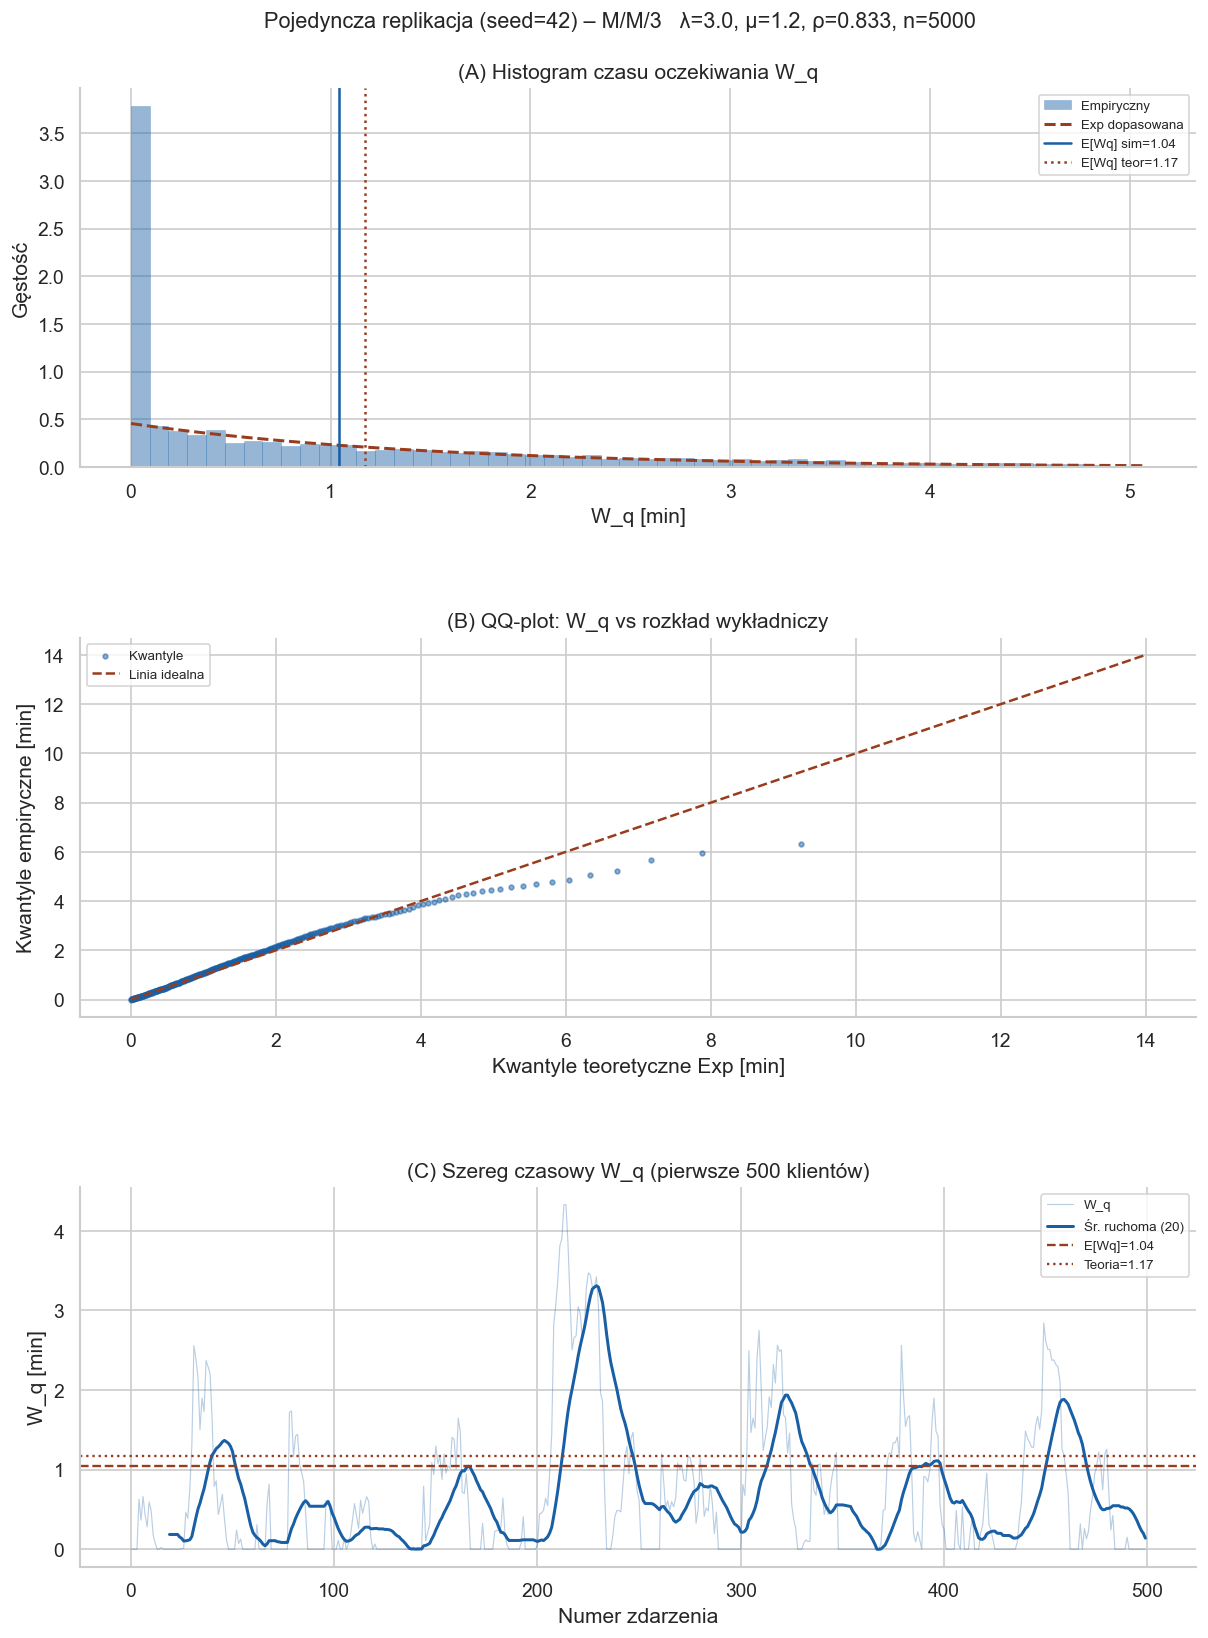

In [ ]:
BLUE   = "#185FA5"
RED    = "#993C1D"
GREEN  = "#0F6E56"
PURPLE = "#533AB7"
GRAY   = "#888780"

r0   = run_results[0]  
wt   = r0["wt"]
mean = r0["mean_wq"]
zeros_pct = r0["zeros_pct"]
results_r0 = {"queue_lengths": r0["lq"], "event_times": r0["event_times"]}

fig2 = plt.figure(figsize=(12, 16))
gs2  = gridspec.GridSpec(3, 1, figure=fig2, hspace=0.45)

ax1 = fig2.add_subplot(gs2[0, 0])
bins = np.linspace(0, np.percentile(wt, 99), 55)
ax1.hist(wt, bins=bins, density=True, color=BLUE, alpha=0.45,
         edgecolor=BLUE, linewidth=0.3, label="Empiryczny")

wt_pos = wt[wt > 0]
x_exp  = np.linspace(0.001, bins[-1], 300)
rate   = 1 / np.mean(wt_pos)
y_exp  = rate * np.exp(-rate * x_exp) * (1 - zeros_pct / 100)

ax1.plot(x_exp, y_exp, color=RED, lw=1.8, ls="--", label="Exp dopasowana")
ax1.axvline(mean, color=BLUE, lw=1.5, ls="-", label=f"E[Wq] sim={mean:.2f}")
ax1.axvline(theory["Wq"], color=RED, lw=1.5, ls=":", label=f"E[Wq] teor={theory['Wq']:.2f}")
ax1.set_xlabel("W_q [min]")
ax1.set_ylabel("Gęstość")
ax1.set_title("(A) Histogram czasu oczekiwania W_q")
ax1.legend(fontsize=8)

ax2 = fig2.add_subplot(gs2[1, 0])
sorted_wt = np.sort(wt_pos)
n_pos     = len(sorted_wt)
probs     = (np.arange(1, n_pos + 1) - 0.5) / n_pos
theoret   = -np.mean(wt_pos) * np.log(1 - probs)
step      = max(1, n_pos // 300)

ax2.scatter(theoret[::step], sorted_wt[::step],
            s=8, alpha=0.5, color=BLUE, label="Kwantyle")

lim = max(theoret[-1], sorted_wt[-1]) * 1.05
ax2.plot([0, lim], [0, lim], color=RED, lw=1.5, ls="--", label="Linia idealna")

ax2.set_xlabel("Kwantyle teoretyczne Exp [min]")
ax2.set_ylabel("Kwantyle empiryczne [min]")
ax2.set_title("(B) QQ-plot: W_q vs rozkład wykładniczy")
ax2.legend(fontsize=8)

ax3 = fig2.add_subplot(gs2[2, 0])
n_ts = min(500, len(wt))
idx  = np.arange(n_ts)

ax3.plot(idx, wt[:n_ts], color=BLUE, alpha=0.30, lw=0.7, label="W_q")

win = 20
ma  = np.convolve(wt[:n_ts], np.ones(win)/win, mode="valid")
ax3.plot(np.arange(win-1, n_ts), ma, color=BLUE, lw=1.8,
         label=f"Śr. ruchoma ({win})")

ax3.axhline(mean, color=RED, lw=1.4, ls="--", label=f"E[Wq]={mean:.2f}")
ax3.axhline(theory["Wq"], color=RED, lw=1.4, ls=":", label=f"Teoria={theory['Wq']:.2f}")

ax3.set_xlabel("Numer zdarzenia")
ax3.set_ylabel("W_q [min]")
ax3.set_title("(C) Szereg czasowy W_q (pierwsze 500 klientów)")
ax3.legend(fontsize=8)

plt.suptitle(
    f"Pojedyncza replikacja (seed=42) – M/M/{C}   λ={LAMBDA}, μ={MU}, ρ={RHO:.3f}, n={N_CUSTOMERS}",
    fontsize=13, y=0.92
)

plt.show()